[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/04-muscle-force.ipynb)

# 04 — Muscle Force Generation and Motor Control

**BMED365 – Computational Medicine (Lab 5)**

_Arvid Lundervold w/ Claude (Anthropic) — 2026-02-15_<br>
_Updated: 2026-02-15_ (Cursor with Claude Opus 4.6)

---

## 1. Motivation & Learning Objectives

### Why study muscle force generation and motor control?

Every voluntary movement — from the blink of an eye to the swing of a tennis racket — originates in an exquisitely orchestrated chain of events: the brain formulates a motor plan, spinal motor neurons fire action potentials, and skeletal muscles contract by converting electrochemical signals into mechanical force. **Understanding this chain is central to biomedicine, rehabilitation, sports science, and robotics.**

Muscle is the body's engine. It accounts for roughly **40% of total body mass** and is the sole effector through which the nervous system interacts with the physical world. Despite its everyday familiarity, the quantitative understanding of muscle contraction required breakthroughs spanning more than a century — from A.V. Hill's thermodynamic experiments in the 1920s, through the discovery of the sliding filament mechanism in 1954, to modern computational models that can predict force output from neural drive.

Computational models of muscle and motor control are now indispensable tools in:

- **Clinical medicine** — understanding neuromuscular diseases (e.g. ALS, muscular dystrophy, spasticity after stroke)
- **Rehabilitation engineering** — designing functional electrical stimulation (FES) protocols for paralyzed limbs
- **Prosthetics and orthotics** — creating powered exoskeletons and myoelectric prostheses
- **Sports science** — optimizing training regimes and predicting injury risk
- **Robotics** — building biologically inspired actuators and controllers for humanoid robots
- **Surgical planning** — simulating musculoskeletal surgery outcomes (e.g. tendon transfer, joint replacement)

### What you will learn

In this notebook you will:

1. **Understand** the hierarchical structure of skeletal muscle — from whole muscle down to the molecular machinery of actin and myosin
2. **Appreciate** the historical context — how Hill, Huxley, and others built our quantitative understanding of contraction
3. **Master** the key mathematical relationships: force-length, force-velocity, and activation dynamics
4. **Implement** a Hill-type muscle model in Python and simulate isometric and isotonic contractions
5. **Explore** motor unit recruitment and the size principle (Henneman's principle)
6. **Simulate** motor control — from neural command signals to limb movement
7. **Connect** human muscle physiology to robotic actuator design and control
8. **Examine** clinical implications — from muscle fatigue to neuromuscular disease

## 2. Historical Context: From Frogs' Legs to Molecular Motors

### A timeline of discovery

The science of muscle contraction has a rich history intertwined with some of the most fundamental advances in physiology, biophysics, and biomechanics.

| Year | Milestone | Scientists |
|------|-----------|-----------|
| 1791 | "Animal electricity" — frog leg twitches from electrical stimulation | Luigi **Galvani** |
| 1840s | First measurements of heat produced during muscle contraction | Hermann von **Helmholtz** |
| 1922 | Thermodynamic analysis of muscle: heat = activation heat + shortening heat | Archibald Vivian **Hill** |
| 1938 | **Hill's equation** — the hyperbolic force-velocity relationship | A.V. **Hill** (Nobel Prize 1922) |
| 1949 | Discovery of the sarcomere's banding pattern by electron microscopy | H.E. **Huxley** |
| 1953 | X-ray diffraction studies of muscle structure | Hugh **Huxley** |
| 1954 | **Sliding filament theory** — simultaneously and independently proposed | H.E. **Huxley** & J. **Hanson**; A.F. **Huxley** & R. **Niedergerke** |
| 1957 | Cross-bridge theory — molecular model of force generation | A.F. **Huxley** |
| 1965 | **Size principle** of motor unit recruitment | Elwood **Henneman** |
| 1969 | Refined Hill-type muscle model with activation dynamics | Felix **Zajac** (later, 1989) |
| 1971 | Swinging cross-bridge model with biochemical states | A.F. Huxley & R.M. **Simmons** |
| 2000s | Large-scale musculoskeletal simulations (OpenSim) | Scott **Delp** et al. |
| 2010s | Bioinspired robotic actuators mimicking muscle properties | Various groups |

### The two Huxleys

A common source of confusion: **Hugh Erskine Huxley** (1924–2013) and **Sir Andrew Fielding Huxley** (1917–2012) were *not related*. Both made independent, complementary contributions to our understanding of muscle:

- **H.E. Huxley** used electron microscopy and X-ray diffraction to reveal the structural basis of contraction
- **A.F. Huxley** (who also co-authored the Hodgkin-Huxley model of the action potential!) developed the mathematical cross-bridge theory

A.F. Huxley received the **Nobel Prize in Physiology or Medicine in 1963** (shared with Hodgkin and Eccles) for work on nerve impulses — but his muscle work was equally groundbreaking.

### A.V. Hill and the force-velocity relationship

**Archibald Vivian Hill** (1886–1977) was a British physiologist who received the **Nobel Prize in Physiology or Medicine in 1922** for discoveries relating to heat production in muscle. His most lasting contribution to muscle mechanics came in 1938, when he published the **force-velocity equation** — a simple hyperbolic relationship that describes how the speed of muscle shortening depends on the load:

$$
(F + a)(v + b) = (F_0 + a) \cdot b
$$

where $F$ is the muscle force, $v$ is the shortening velocity, $F_0$ is the maximum isometric force, and $a$, $b$ are constants related to the muscle's thermodynamic properties. This remarkably simple equation remains the foundation of virtually all computational muscle models used today.

> *"The combination of observation and of theory, which is necessary if physiology is to develop as a science, requires at every point that theory should be tested by observation, and observation should be guided by theory."* — A.V. Hill

In [1]:
from IPython.display import Image, display, HTML, Markdown
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Set default plot style
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 100
})

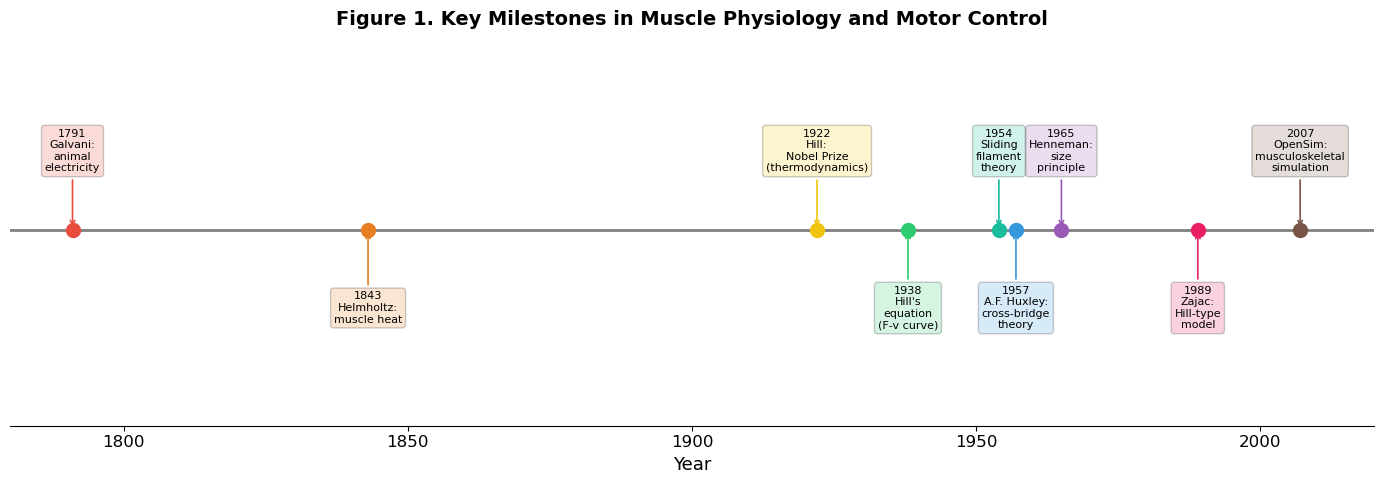

In [2]:
# --- Figure 1: Timeline of key discoveries in muscle physiology ---

fig, ax = plt.subplots(figsize=(14, 5))

events = [
    (1791, "Galvani:\nanimal\nelectricity", "#e74c3c"),
    (1843, "Helmholtz:\nmuscle heat", "#e67e22"),
    (1922, "Hill:\nNobel Prize\n(thermodynamics)", "#f1c40f"),
    (1938, "Hill's\nequation\n(F-v curve)", "#2ecc71"),
    (1954, "Sliding\nfilament\ntheory", "#1abc9c"),
    (1957, "A.F. Huxley:\ncross-bridge\ntheory", "#3498db"),
    (1965, "Henneman:\nsize\nprinciple", "#9b59b6"),
    (1989, "Zajac:\nHill-type\nmodel", "#e91e63"),
    (2007, "OpenSim:\nmusculoskeletal\nsimulation", "#795548"),
]

y_positions = [1, -1, 1, -1, 1, -1, 1, -1, 1]

for (year, label, color), y_pos in zip(events, y_positions):
    ax.plot(year, 0, 'o', color=color, markersize=10, zorder=5)
    ax.annotate(f"{year}\n{label}", xy=(year, 0), xytext=(year, y_pos * 0.6),
                fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.2),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax.axhline(y=0, color='gray', linewidth=2, zorder=1)
ax.set_xlim(1780, 2020)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Year')
ax.set_title('Figure 1. Key Milestones in Muscle Physiology and Motor Control', fontweight='bold')
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Muscle Structure: From Whole Muscle to Molecular Motors

### The hierarchical organization of skeletal muscle

Skeletal muscle has a beautiful hierarchical structure, with each level of organization serving a specific mechanical and physiological function:

| Level | Structure | Size | Function |
|-------|-----------|------|----------|
| **Whole muscle** | e.g. biceps brachii | ~10–30 cm | Generates movement across joints |
| **Fascicle** | Bundle of fibers | ~1–10 mm diameter | Organized force transmission |
| **Muscle fiber** (cell) | Multinucleated cell | ~10–100 μm diameter, up to 30 cm long | The functional contractile unit |
| **Myofibril** | Cylindrical organelle | ~1–2 μm diameter | Contains the contractile machinery |
| **Sarcomere** | Repeating unit of myofibril | ~2.0–2.5 μm at rest | The fundamental contractile unit |
| **Myofilaments** | Actin (thin) and myosin (thick) | ~5–15 nm diameter | Molecular motors that generate force |

### Muscle fiber types

Not all muscle fibers are the same. Human skeletal muscle contains a mix of fiber types that differ in their contractile speed, fatigue resistance, and metabolic properties:

| Property | Type I (Slow oxidative) | Type IIa (Fast oxidative-glycolytic) | Type IIx (Fast glycolytic) |
|----------|------------------------|--------------------------------------|---------------------------|
| **Contraction speed** | Slow | Fast | Fastest |
| **Fatigue resistance** | Very high | Moderate | Low |
| **Force production** | Low | Moderate | High |
| **Mitochondrial density** | High | Moderate-High | Low |
| **Color** | Red (myoglobin-rich) | Red | White |
| **Primary use** | Posture, endurance | Mixed activities | Explosive movements |
| **Example** | Soleus (standing) | Gastrocnemius | Quadriceps (sprinting) |

The mix of fiber types varies between muscles and between individuals — elite marathon runners have a higher proportion of Type I fibers, while sprinters have more Type II fibers.

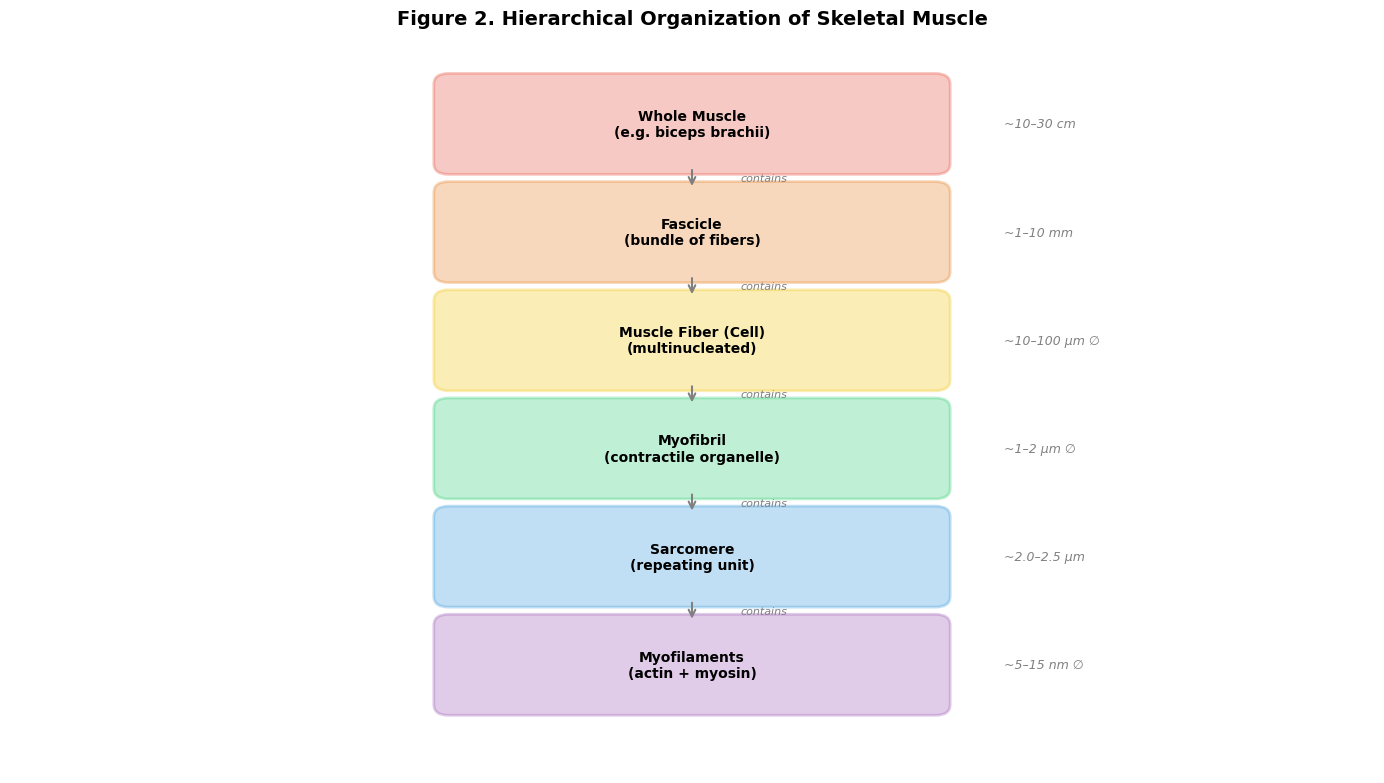

In [4]:
# --- Figure 2: Hierarchical structure of skeletal muscle ---

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Figure 2. Hierarchical Organization of Skeletal Muscle', fontweight='bold', fontsize=14, pad=20)

# Define levels from top to bottom
levels = [
    (7, 9.0, 'Whole Muscle\n(e.g. biceps brachii)', '#e74c3c', '~10–30 cm'),
    (7, 7.5, 'Fascicle\n(bundle of fibers)', '#e67e22', '~1–10 mm'),
    (7, 6.0, 'Muscle Fiber (Cell)\n(multinucleated)', '#f1c40f', '~10–100 μm ∅'),
    (7, 4.5, 'Myofibril\n(contractile organelle)', '#2ecc71', '~1–2 μm ∅'),
    (7, 3.0, 'Sarcomere\n(repeating unit)', '#3498db', '~2.0–2.5 μm'),
    (7, 1.5, 'Myofilaments\n(actin + myosin)', '#9b59b6', '~5–15 nm ∅'),
]

for i, (x, y, label, color, size) in enumerate(levels):
    # Main box
    box = mpatches.FancyBboxPatch((x - 2.5, y - 0.55), 5, 1.1,
                                   boxstyle="round,pad=0.15", facecolor=color, alpha=0.3,
                                   edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold')
    # Size annotation
    ax.text(x + 3.2, y, size, ha='left', va='center', fontsize=9, style='italic', color='gray')
    # Arrow to next level
    if i < len(levels) - 1:
        ax.annotate('', xy=(x, levels[i+1][1] + 0.6), xytext=(x, y - 0.6),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Add "contains" labels
for i in range(len(levels) - 1):
    mid_y = (levels[i][1] - 0.6 + levels[i+1][1] + 0.6) / 2
    ax.text(7.5, mid_y, 'contains', ha='left', va='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.show()

## 4. The Sliding Filament Theory and the Cross-Bridge Cycle

### The sliding filament theory (1954)

The **sliding filament theory** is one of the most important discoveries in biology. Proposed independently in 1954 by two pairs of scientists — **H.E. Huxley & Jean Hanson** and **A.F. Huxley & Rolf Niedergerke** — it states that:

> **Muscle contraction occurs because the thin (actin) and thick (myosin) filaments slide past each other, without the filaments themselves changing length.**

This was revolutionary because earlier theories assumed that the protein filaments shortened like coiling springs. The sliding filament theory explained why:
- The **A-band** (region of thick filaments) stays constant in width during contraction
- The **I-band** (region of thin filaments only) narrows
- The **H-zone** (region of thick filaments only) narrows
- The overall **sarcomere** shortens

### The sarcomere: the fundamental contractile unit

The sarcomere is bounded by **Z-discs** (or Z-lines) and contains:
- **Thin filaments (actin)**: anchored at the Z-disc, extend toward the center
- **Thick filaments (myosin)**: centered in the sarcomere, with globular "heads" that can bind to actin
- **Titin**: a giant elastic protein connecting the thick filament to the Z-disc, providing passive stiffness
- **Regulatory proteins**: troponin and tropomyosin on actin filaments, which control access to myosin binding sites

### The cross-bridge cycle

Force generation occurs through the **cross-bridge cycle** — a repeating sequence of molecular events powered by ATP hydrolysis:

1. **Attachment**: Myosin head binds to actin (forms a "cross-bridge")
2. **Power stroke**: Myosin head pivots, pulling the actin filament toward the center of the sarcomere (force generation!)
3. **Detachment**: ATP binds to myosin, causing it to release from actin
4. **Recovery stroke**: ATP is hydrolyzed (→ ADP + Pi), re-cocking the myosin head for the next cycle

Each cycle moves the actin filament by about **5–10 nm** and generates a force of about **2–4 pN** (piconewtons). A single muscle fiber contains billions of cross-bridges operating asynchronously, producing smooth, sustained force.

### Excitation-contraction coupling

The link between the neural signal and contraction involves:

1. **Motor neuron** fires an action potential
2. Acetylcholine released at the **neuromuscular junction**
3. Action potential propagates along the muscle fiber membrane (sarcolemma) and into **T-tubules**
4. Ca²⁺ released from the **sarcoplasmic reticulum** (SR)
5. Ca²⁺ binds to **troponin**, causing **tropomyosin** to shift and expose myosin binding sites on actin
6. **Cross-bridge cycling** begins → force generation
7. Ca²⁺ pumped back into SR → relaxation

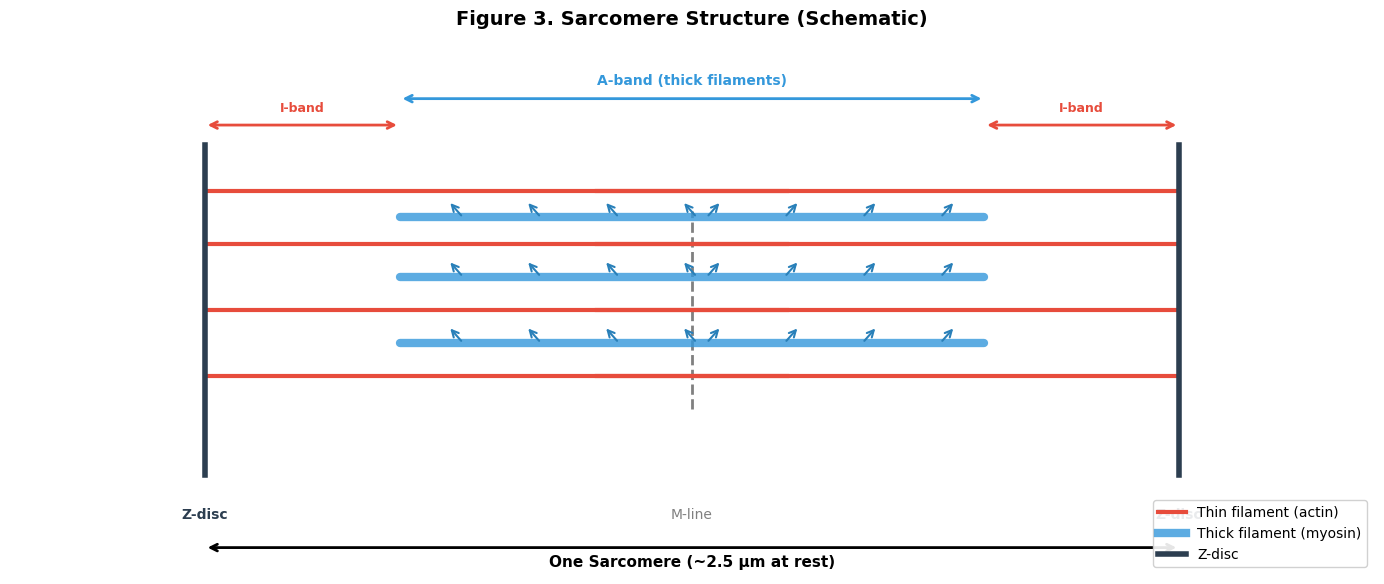

In [5]:
# --- Figure 3: Sarcomere structure diagram ---

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Figure 3. Sarcomere Structure (Schematic)', fontweight='bold', fontsize=14, pad=15)

# Z-discs
for x in [2, 12]:
    ax.plot([x, x], [1.5, 6.5], color='#2c3e50', linewidth=4, zorder=5)
    ax.text(x, 1.0, 'Z-disc', ha='center', va='top', fontsize=10, fontweight='bold', color='#2c3e50')

# M-line
ax.plot([7, 7], [2.5, 5.5], color='gray', linewidth=2, linestyle='--', zorder=3)
ax.text(7, 1.0, 'M-line', ha='center', va='top', fontsize=10, color='gray')

# Thin filaments (actin) - from Z-discs toward center
actin_y_positions = [3.0, 4.0, 5.0, 5.8]
for y in actin_y_positions:
    # Left actin
    ax.plot([2, 8], [y, y], color='#e74c3c', linewidth=3, solid_capstyle='round', zorder=4)
    # Right actin
    ax.plot([6, 12], [y, y], color='#e74c3c', linewidth=3, solid_capstyle='round', zorder=4)

# Thick filaments (myosin) - centered
myosin_y = [3.5, 4.5, 5.4]
for y in myosin_y:
    ax.plot([4, 10], [y, y], color='#3498db', linewidth=6, solid_capstyle='round', zorder=3, alpha=0.8)
    # Myosin heads (cross-bridges)
    for x_head in np.arange(4.5, 7, 0.8):
        ax.annotate('', xy=(x_head, y + 0.25), xytext=(x_head + 0.15, y),
                    arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.5))
    for x_head in np.arange(7.3, 9.8, 0.8):
        ax.annotate('', xy=(x_head, y + 0.25), xytext=(x_head - 0.15, y),
                    arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.5))

# Band labels
ax.annotate('', xy=(4, 7.2), xytext=(10, 7.2),
            arrowprops=dict(arrowstyle='<->', color='#3498db', lw=2))
ax.text(7, 7.4, 'A-band (thick filaments)', ha='center', fontsize=10, color='#3498db', fontweight='bold')

ax.annotate('', xy=(2, 6.8), xytext=(4, 6.8),
            arrowprops=dict(arrowstyle='<->', color='#e74c3c', lw=2))
ax.text(3, 7.0, 'I-band', ha='center', fontsize=9, color='#e74c3c', fontweight='bold')

ax.annotate('', xy=(10, 6.8), xytext=(12, 6.8),
            arrowprops=dict(arrowstyle='<->', color='#e74c3c', lw=2))
ax.text(11, 7.0, 'I-band', ha='center', fontsize=9, color='#e74c3c', fontweight='bold')

# Sarcomere bracket
ax.annotate('', xy=(2, 0.4), xytext=(12, 0.4),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(7, 0.1, 'One Sarcomere (~2.5 μm at rest)', ha='center', fontsize=11, fontweight='bold')

# Legend
ax.plot([], [], color='#e74c3c', linewidth=3, label='Thin filament (actin)')
ax.plot([], [], color='#3498db', linewidth=6, alpha=0.8, label='Thick filament (myosin)')
ax.plot([], [], color='#2c3e50', linewidth=4, label='Z-disc')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

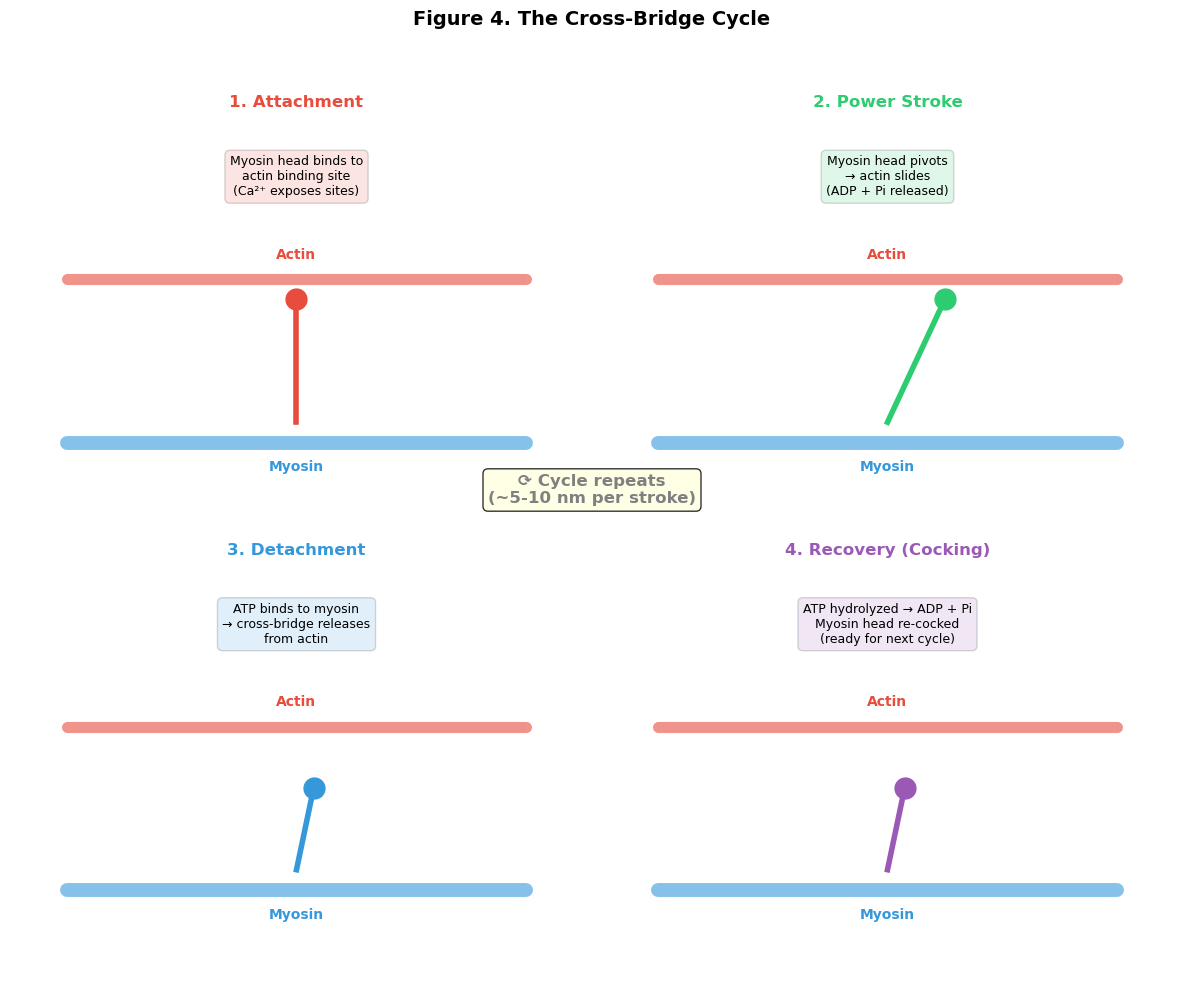

In [6]:
# --- Figure 4: Cross-bridge cycle diagram ---

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Figure 4. The Cross-Bridge Cycle', fontweight='bold', fontsize=14, y=0.98)

steps = [
    ('1. Attachment', 'Myosin head binds to\nactin binding site\n(Ca²⁺ exposes sites)', '#e74c3c', True),
    ('2. Power Stroke', 'Myosin head pivots\n→ actin slides\n(ADP + Pi released)', '#2ecc71', True),
    ('3. Detachment', 'ATP binds to myosin\n→ cross-bridge releases\nfrom actin', '#3498db', False),
    ('4. Recovery (Cocking)', 'ATP hydrolyzed → ADP + Pi\nMyosin head re-cocked\n(ready for next cycle)', '#9b59b6', False),
]

for ax, (title, desc, color, attached) in zip(axes.flat, steps):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Actin filament
    ax.plot([1, 9], [6, 6], color='#e74c3c', linewidth=8, solid_capstyle='round', alpha=0.6)
    ax.text(5, 6.5, 'Actin', ha='center', fontsize=10, color='#e74c3c', fontweight='bold')

    # Myosin backbone
    ax.plot([1, 9], [2, 2], color='#3498db', linewidth=10, solid_capstyle='round', alpha=0.6)
    ax.text(5, 1.3, 'Myosin', ha='center', fontsize=10, color='#3498db', fontweight='bold')

    # Myosin head (cross-bridge)
    if attached:
        # Head touching actin
        head_angle = 45 if '1' in title else 80
        head_x = 5 if '1' in title else 6
        ax.plot([5, head_x], [2.5, 5.5], color=color, linewidth=4, zorder=5)
        ax.plot(head_x, 5.5, 'o', color=color, markersize=15, zorder=6)
    else:
        # Head away from actin
        ax.plot([5, 5.3], [2.5, 4.5], color=color, linewidth=4, zorder=5)
        ax.plot(5.3, 4.5, 'o', color=color, markersize=15, zorder=6)

    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.text(5, 8.5, desc, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.15))

# Add cycle arrows between panels
fig.text(0.5, 0.5, '⟳ Cycle repeats\n(~5-10 nm per stroke)', ha='center', va='center',
         fontsize=12, fontweight='bold', color='gray',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Check Your Understanding: Muscle Structure and the Cross-Bridge Cycle

**Q1.** During the sliding filament mechanism, which of the following changes length? (a) The thick filament, (b) The thin filament, (c) The sarcomere, (d) Both filaments.

<details>
<summary>Click to reveal answer</summary>

**(c) The sarcomere** changes length (shortens). Neither the thick (myosin) nor the thin (actin) filaments change length — they slide past each other. This is the central insight of the sliding filament theory: the sarcomere shortens because the filaments overlap more, not because they contract individually.

</details>

---

**Q2.** What role does calcium (Ca²⁺) play in muscle contraction?

<details>
<summary>Click to reveal answer</summary>

Ca²⁺ is the key trigger for contraction. When released from the sarcoplasmic reticulum:
1. Ca²⁺ binds to **troponin** on the thin filament
2. This causes **tropomyosin** to shift, exposing the myosin binding sites on actin
3. Cross-bridge cycling can now begin

Without Ca²⁺, the binding sites remain blocked and no contraction occurs. This is why rigor mortis occurs after death — ATP depletion prevents Ca²⁺ from being pumped back into the SR, so cross-bridges remain permanently attached.

</details>

---

**Q3.** Why does ATP need to bind to myosin for muscle *relaxation* (not just contraction)?

<details>
<summary>Click to reveal answer</summary>

ATP binding to the myosin head is required for **detachment** from actin (step 3 of the cross-bridge cycle). Without ATP, the myosin head remains locked onto actin in a "rigor" state. This is why:
- **Rigor mortis** occurs after death (no ATP → permanent cross-bridge attachment)
- Muscle contraction is often described as requiring ATP for both contraction *and* relaxation

The energy from ATP hydrolysis is then used to re-cock the myosin head for the next power stroke.

</details>

## 5. Scientific and Clinical Implications

### Why computational muscle models matter in medicine

Understanding muscle force generation quantitatively has profound implications across many areas of medicine and biomedical engineering:

### Neuromuscular diseases

| Disease | What goes wrong | How models help |
|---------|-----------------|-----------------|
| **Muscular dystrophy** | Progressive muscle fiber degeneration (e.g. dystrophin deficiency in Duchenne MD) | Predict force loss as fiber population changes; optimize rehabilitation |
| **ALS (Lou Gehrig's disease)** | Motor neuron death → progressive paralysis | Model motor unit loss and remaining capacity; plan FES interventions |
| **Myasthenia gravis** | Antibodies block acetylcholine receptors at NMJ | Simulate reduced neuromuscular transmission efficiency |
| **Spasticity (post-stroke)** | Loss of inhibitory control → excessive muscle tone | Model altered recruitment patterns and co-contraction |
| **Sarcopenia** | Age-related loss of muscle mass and motor units | Predict functional decline; design exercise interventions |

### Rehabilitation and prosthetics

- **Functional Electrical Stimulation (FES)**: Computational models predict optimal stimulation patterns to produce desired movements in paralyzed limbs
- **Myoelectric prostheses**: EMG-based control algorithms use muscle models to decode intended movements from residual muscle signals
- **Exoskeletons**: Human-robot interaction models must account for the nonlinear force-length-velocity properties of muscle
- **Tendon transfer surgery**: Surgeons use musculoskeletal simulations (e.g. OpenSim) to predict functional outcomes of surgical procedures

### Sports science and ergonomics

- **Injury prediction**: Models of muscle strain during eccentric contractions help identify injury-prone conditions
- **Performance optimization**: Simulations can identify which muscles limit performance in specific movements
- **Fatigue modeling**: Understanding how repeated contractions degrade force output
- **Workplace ergonomics**: Predicting muscle fatigue and injury risk from repetitive tasks

### Cardiac muscle

The same cross-bridge principles apply to cardiac muscle, where computational models are used to:
- Simulate heart contraction and predict cardiac output
- Understand cardiomyopathies at the molecular level
- Design and test cardiac assist devices

## 6. The Hill Muscle Model: Conceptual Framework

### From biology to engineering

To simulate muscle force computationally, we need a model that is biologically meaningful yet tractable enough to embed in larger simulations. The **Hill-type muscle model** (refined by Zajac, 1989) achieves this by representing the muscle-tendon unit as a combination of mechanical elements:

| Element | Symbol | Represents | Property |
|---------|--------|------------|----------|
| **Contractile Element** | CE | Active cross-bridge force generation | Force depends on length, velocity, and activation |
| **Series Elastic Element** | SEE | Tendon + aponeurosis | Stores and releases elastic energy |
| **Parallel Elastic Element** | PEE | Passive connective tissue, titin | Resists stretch at extreme lengths |

### The key relationships

The Hill-type model captures three fundamental properties of muscle:

1. **Force-Length Relationship** $f_L(\tilde{l})$: Active force is maximal at an optimal sarcomere length and decreases at shorter and longer lengths (the "inverted U" curve)

2. **Force-Velocity Relationship** $f_V(\tilde{v})$: 
   - During **shortening** (concentric): force *decreases* with increasing velocity (Hill's equation)
   - During **lengthening** (eccentric): force *increases* above isometric maximum (up to ~1.5–1.8× $F_0$)

3. **Activation Dynamics** $a(t)$: The time-dependent process of Ca²⁺ release and reuptake, converting the neural excitation $u(t)$ into a muscle activation level $a(t) \in [0, 1]$

The total active muscle force is:

$$
F_{\text{muscle}} = a(t) \cdot F_0 \cdot f_L(\tilde{l}) \cdot f_V(\tilde{v}) + F_{\text{passive}}(\tilde{l})
$$

where:
- $a(t)$ is the activation level (0 = relaxed, 1 = fully activated)
- $F_0$ is the maximum isometric force at optimal length
- $f_L$ is the normalized force-length factor
- $f_V$ is the normalized force-velocity factor
- $\tilde{l} = l/l_0$ is the normalized muscle length
- $\tilde{v} = v/v_{\max}$ is the normalized shortening velocity
- $F_{\text{passive}}$ is the passive elastic force

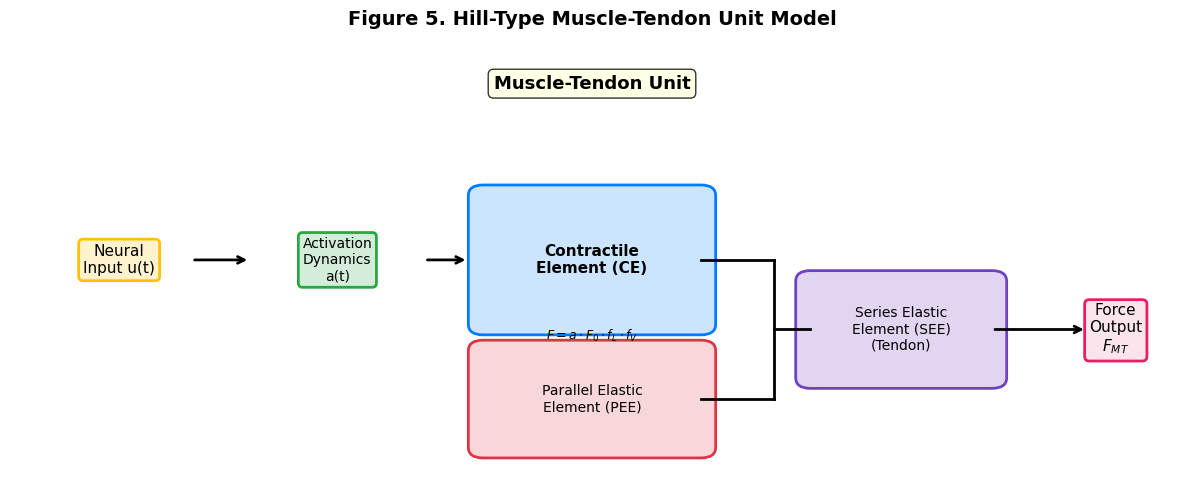

In [7]:
# --- Figure 5: Hill muscle model schematic ---

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Figure 5. Hill-Type Muscle-Tendon Unit Model', fontweight='bold', fontsize=14, pad=15)

# Neural input (left)
ax.annotate('Neural\nInput u(t)', xy=(1.5, 4), fontsize=11, ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='#fff3cd', edgecolor='#ffc107', linewidth=2))

# Arrow from neural input to activation
ax.annotate('', xy=(3.3, 4), xytext=(2.5, 4),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Activation dynamics box
ax.text(4.5, 4, 'Activation\nDynamics\na(t)', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#d4edda', edgecolor='#28a745', linewidth=2))

# Arrow from activation to CE
ax.annotate('', xy=(6.3, 4), xytext=(5.7, 4),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Contractile Element (CE)
ce_box = mpatches.FancyBboxPatch((6.5, 2.8), 3, 2.4, boxstyle="round,pad=0.2",
                                  facecolor='#cce5ff', edgecolor='#007bff', linewidth=2)
ax.add_patch(ce_box)
ax.text(8, 4, 'Contractile\nElement (CE)', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(8, 2.5, '$F = a \\cdot F_0 \\cdot f_L \\cdot f_V$', ha='center', fontsize=9, style='italic')

# Parallel Elastic Element (PEE) - parallel to CE
pee_box = mpatches.FancyBboxPatch((6.5, 0.5), 3, 1.8, boxstyle="round,pad=0.2",
                                   facecolor='#f8d7da', edgecolor='#dc3545', linewidth=2)
ax.add_patch(pee_box)
ax.text(8, 1.4, 'Parallel Elastic\nElement (PEE)', ha='center', va='center', fontsize=10)

# Connection lines (CE + PEE combined)
ax.plot([9.5, 10.5], [4, 4], 'k-', linewidth=2)
ax.plot([9.5, 10.5], [1.4, 1.4], 'k-', linewidth=2)
ax.plot([10.5, 10.5], [1.4, 4], 'k-', linewidth=2)
ax.plot([10.5, 11], [2.7, 2.7], 'k-', linewidth=2)

# Series Elastic Element (SEE) - in series
see_box = mpatches.FancyBboxPatch((11, 1.8), 2.5, 1.8, boxstyle="round,pad=0.2",
                                   facecolor='#e2d5f1', edgecolor='#6f42c1', linewidth=2)
ax.add_patch(see_box)
ax.text(12.25, 2.7, 'Series Elastic\nElement (SEE)\n(Tendon)', ha='center', va='center', fontsize=10)

# Output arrow
ax.annotate('', xy=(14.8, 2.7), xytext=(13.5, 2.7),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(15.2, 2.7, 'Force\nOutput\n$F_{MT}$', ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#fce4ec', edgecolor='#e91e63', linewidth=2))

# Labels
ax.text(8, 7.2, 'Muscle-Tendon Unit', ha='center', fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

## 7. Mathematical Formulation

### 7.1 Force-Length Relationship

The active force-length relationship arises directly from the sliding filament theory: force depends on the degree of overlap between actin and myosin filaments. At the **optimal length** $l_0$, overlap is maximal and the most cross-bridges can form. Force drops at shorter lengths (filament collision and interference) and at longer lengths (reduced overlap).

A commonly used Gaussian approximation is:

$$
f_L(\tilde{l}) = \exp\left[-\left(\frac{\tilde{l} - 1}{\gamma}\right)^2\right]
$$

where $\tilde{l} = l/l_0$ is the normalized fiber length and $\gamma \approx 0.45$ controls the width of the curve.

The **passive force** (from titin and connective tissue) increases exponentially at long lengths:

$$
f_{\text{passive}}(\tilde{l}) = \begin{cases} k_{PE} \cdot (\tilde{l} - 1)^2 & \text{if } \tilde{l} > 1 \\ 0 & \text{if } \tilde{l} \leq 1 \end{cases}
$$

### 7.2 Force-Velocity Relationship (Hill's Equation)

A.V. Hill's 1938 equation describes the hyperbolic relationship between force and shortening velocity. In normalized form:

**Shortening** ($\tilde{v} < 0$, concentric contraction):
$$
f_V(\tilde{v}) = \frac{1 + \tilde{v}/\tilde{v}_{\max}}{1 - \tilde{v}/(\tilde{v}_{\max} \cdot A_f)}
$$

where $A_f \approx 0.25$ is a shape factor.

**Lengthening** ($\tilde{v} > 0$, eccentric contraction):
$$
f_V(\tilde{v}) = \frac{F_{\text{ecc,max}} - (F_{\text{ecc,max}} - 1) \cdot \frac{1 + \tilde{v}/\tilde{v}_{\max}}{1 - \tilde{v} \cdot k_{ecc} / (\tilde{v}_{\max} \cdot A_f)}}{1}
$$

For simplicity, we will use a piecewise rational function that captures the essential behavior.

### 7.3 Activation Dynamics

The neural excitation $u(t) \in [0,1]$ is transformed into muscle activation $a(t) \in [0,1]$ through first-order dynamics representing Ca²⁺ kinetics:

$$
\frac{da}{dt} = \frac{u(t) - a(t)}{\tau(u, a)}
$$

where the time constant differs for activation and deactivation:

$$
\tau(u, a) = \begin{cases} \tau_{\text{act}} = 10\text{–}20 \text{ ms} & \text{if } u > a \text{ (activation)} \\ \tau_{\text{deact}} = 40\text{–}60 \text{ ms} & \text{if } u \leq a \text{ (deactivation)} \end{cases}
$$

Activation is faster than deactivation because Ca²⁺ release from the SR is faster than reuptake — an asymmetry with important functional consequences for motor control.

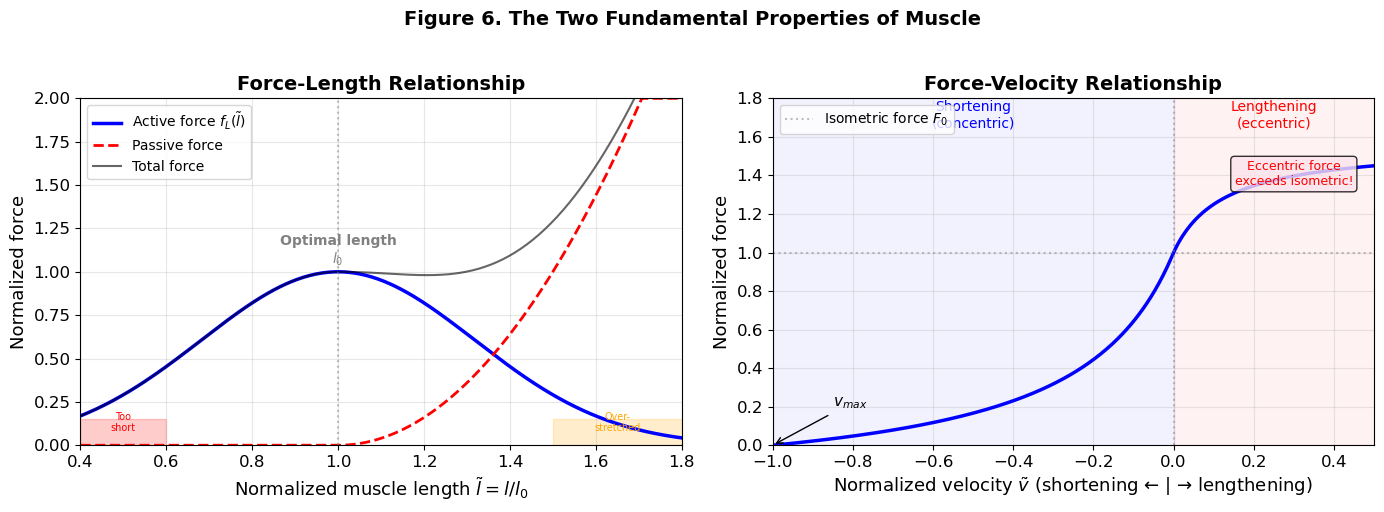

In [8]:
# --- Figure 6: Force-Length and Force-Velocity Relationships ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Force-Length relationship ----
ax = axes[0]
l_norm = np.linspace(0.4, 1.8, 300)
gamma = 0.45

# Active force-length
f_active = np.exp(-((l_norm - 1.0) / gamma)**2)

# Passive force-length
k_pe = 4.0
f_passive = np.where(l_norm > 1.0, k_pe * (l_norm - 1.0)**2, 0)
f_passive = np.minimum(f_passive, 2.0)  # Cap for display

# Total force
f_total = f_active + f_passive

ax.plot(l_norm, f_active, 'b-', linewidth=2.5, label='Active force $f_L(\\tilde{l})$')
ax.plot(l_norm, f_passive, 'r--', linewidth=2, label='Passive force')
ax.plot(l_norm, f_total, 'k-', linewidth=1.5, alpha=0.6, label='Total force')
ax.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5)
ax.annotate('Optimal length\n$l_0$', xy=(1.0, 1.05), ha='center', fontsize=10,
            color='gray', fontweight='bold')

# Sarcomere length context
ax.fill_betweenx([0, 0.15], 0.4, 0.6, alpha=0.2, color='red')
ax.fill_betweenx([0, 0.15], 1.5, 1.8, alpha=0.2, color='orange')
ax.text(0.5, 0.08, 'Too\nshort', ha='center', fontsize=7, color='red')
ax.text(1.65, 0.08, 'Over-\nstretched', ha='center', fontsize=7, color='orange')

ax.set_xlabel('Normalized muscle length $\\tilde{l} = l/l_0$')
ax.set_ylabel('Normalized force')
ax.set_title('Force-Length Relationship', fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(0.4, 1.8)
ax.set_ylim(0, 2.0)
ax.grid(True, alpha=0.3)

# ---- Force-Velocity relationship ----
ax = axes[1]
v_norm = np.linspace(-1.0, 0.5, 300)  # negative = shortening, positive = lengthening

# Hill-type force-velocity
Af = 0.25  # shape factor
f_ecc_max = 1.5  # maximum eccentric force ratio

f_v = np.zeros_like(v_norm)
for i, v in enumerate(v_norm):
    if v <= 0:  # Shortening (concentric)
        f_v[i] = (1 + v) / (1 - v / Af)
    else:  # Lengthening (eccentric)
        f_v[i] = f_ecc_max - (f_ecc_max - 1) * (1 - v) / (1 + v / (Af * 0.5))

# Clamp values
f_v = np.clip(f_v, 0, 1.8)

ax.plot(v_norm, f_v, 'b-', linewidth=2.5)
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5, label='Isometric force $F_0$')
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# Annotations
ax.fill_betweenx([0, 1.8], -1.0, 0, alpha=0.05, color='blue')
ax.fill_betweenx([0, 1.8], 0, 0.5, alpha=0.05, color='red')
ax.text(-0.5, 1.65, 'Shortening\n(concentric)', ha='center', fontsize=10, color='blue')
ax.text(0.25, 1.65, 'Lengthening\n(eccentric)', ha='center', fontsize=10, color='red')

ax.annotate('$v_{max}$', xy=(-1.0, 0), fontsize=11, fontweight='bold',
            xytext=(-0.85, 0.2), arrowprops=dict(arrowstyle='->', color='black'))
ax.annotate('Eccentric force\nexceeds isometric!', xy=(0.3, 1.35), fontsize=9,
            color='red', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fce4ec', alpha=0.8))

ax.set_xlabel('Normalized velocity $\\tilde{v}$ (shortening ← | → lengthening)')
ax.set_ylabel('Normalized force')
ax.set_title('Force-Velocity Relationship', fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(-1.0, 0.5)
ax.set_ylim(0, 1.8)
ax.grid(True, alpha=0.3)

fig.suptitle('Figure 6. The Two Fundamental Properties of Muscle', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Check Your Understanding: Force-Length and Force-Velocity

**Q4.** A patient has a muscle contracture (the muscle is chronically shortened). Based on the force-length relationship, would you expect this muscle to produce more or less active force than normal at its resting position?

<details>
<summary>Click to reveal answer</summary>

**Less force.** A chronically shortened muscle operates on the ascending limb of the force-length curve (left of the optimal length $l_0$). At this shorter length, there is excessive overlap between actin filaments from opposite sides of the sarcomere (double overlap), and myosin heads may collide with Z-discs — both reducing the number of productive cross-bridges. This is why muscle contractures are functionally debilitating and why stretching programs are important in rehabilitation.

</details>

---

**Q5.** During which type of contraction (concentric or eccentric) is a muscle most likely to be injured? Why?

<details>
<summary>Click to reveal answer</summary>

**Eccentric contractions** are most likely to cause injury (muscle strains). This is because:
1. Eccentric force can exceed the maximum isometric force by 50–80%, placing enormous mechanical stress on the muscle
2. Fewer motor units are recruited for the same force level during eccentric contractions, so the force per active fiber is higher
3. The combination of high force and active lengthening can mechanically disrupt sarcomeres and the cytoskeleton

This is why hamstring injuries are so common in sprinting (the hamstrings undergo forceful eccentric contraction during the late swing phase) and why "delayed onset muscle soreness" (DOMS) occurs after unaccustomed eccentric exercise.

</details>

---

**Q6.** Hill's force-velocity equation shows that a muscle generates zero force at its maximum shortening velocity $v_{\max}$. What does this mean physically?

<details>
<summary>Click to reveal answer</summary>

At $v_{\max}$, the muscle is shortening so fast that cross-bridges cannot maintain attachment long enough to complete a power stroke. The rate of cross-bridge detachment exceeds the rate of attachment, so no net force is generated. The muscle can only move this fast under **zero load** (unloaded shortening). This explains why you can move your hand very quickly when holding nothing, but much more slowly when holding a heavy weight.

Mathematically: at $v = v_{\max}$, $F = 0$ in Hill's equation $(F + a)(v + b) = (F_0 + a)b$.

</details>

## 8. Motor Unit Recruitment and the Size Principle

### What is a motor unit?

A **motor unit** consists of a single **alpha motor neuron** (in the spinal cord) and all the muscle fibers it innervates. It is the fundamental unit of motor control — the smallest unit of force that the nervous system can independently control.

Key properties:
- A single motor neuron may innervate **5 to 2000+** muscle fibers
- All fibers in a motor unit are of the **same type** (Type I, IIa, or IIx)
- All fibers in a motor unit contract **simultaneously** when the motor neuron fires
- The force of a motor unit depends on its **size** (number of fibers) and **firing rate**

### Henneman's size principle (1965)

Elwood Henneman discovered that motor units are recruited in a **fixed order**, from smallest to largest:

1. **Small motor units** (Type I, slow, fatigue-resistant) are recruited first for low-force tasks
2. **Medium motor units** (Type IIa) are added as force demand increases
3. **Large motor units** (Type IIx, fast, fatigable) are recruited last, only for high-force or explosive tasks

This orderly recruitment has elegant functional consequences:
- **Fine control at low forces**: Small increments in force for delicate tasks (e.g. threading a needle)
- **Power when needed**: Large, fast motor units available for emergencies (e.g. catching yourself from falling)
- **Fatigue resistance**: The most fatigue-resistant units are used most, preserving endurance

### Force modulation: two mechanisms

The nervous system controls muscle force through two complementary mechanisms:

1. **Recruitment**: Activating additional motor units (dominant at low force levels, < 50–80% of maximum)
2. **Rate coding**: Increasing the firing rate of already-active motor units (dominant at high force levels)

The combination of recruitment and rate coding gives the motor system an enormous dynamic range — from the few millinewtons needed to hold a feather to the thousands of newtons generated during a maximal jump.

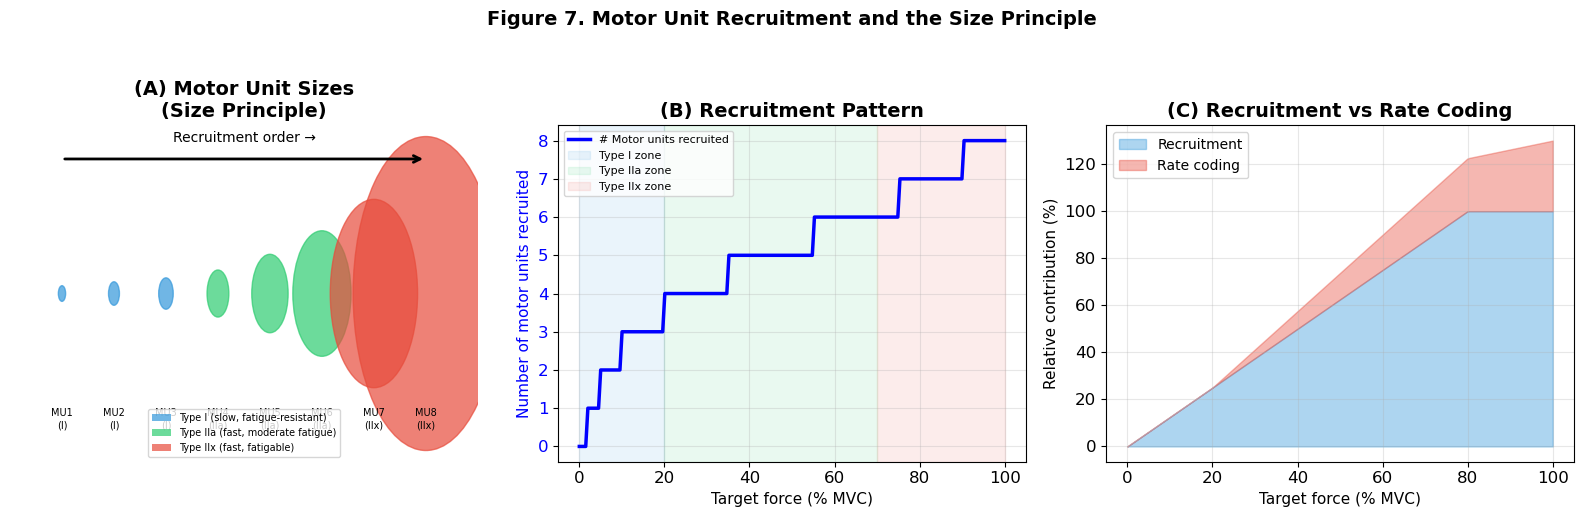

In [9]:
# --- Figure 7: Motor unit recruitment and size principle ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Size principle illustration
ax = axes[0]
n_units = 8
sizes = np.array([1, 1.5, 2, 3, 5, 8, 12, 20])  # Relative sizes
types = ['I', 'I', 'I', 'IIa', 'IIa', 'IIa', 'IIx', 'IIx']
colors_mu = ['#3498db', '#3498db', '#3498db', '#2ecc71', '#2ecc71', '#2ecc71', '#e74c3c', '#e74c3c']

for i in range(n_units):
    circle = plt.Circle((i + 0.5, 1.5), sizes[i] * 0.07, color=colors_mu[i], alpha=0.7)
    ax.add_patch(circle)
    ax.text(i + 0.5, 0.3, f'MU{i+1}\n({types[i]})', ha='center', fontsize=7)

ax.set_xlim(-0.5, 8.5)
ax.set_ylim(0, 3)
ax.set_title('(A) Motor Unit Sizes\n(Size Principle)', fontweight='bold')
ax.annotate('', xy=(7.5, 2.7), xytext=(0.5, 2.7),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(4, 2.85, 'Recruitment order →', ha='center', fontsize=10)
ax.axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', alpha=0.7, label='Type I (slow, fatigue-resistant)'),
    Patch(facecolor='#2ecc71', alpha=0.7, label='Type IIa (fast, moderate fatigue)'),
    Patch(facecolor='#e74c3c', alpha=0.7, label='Type IIx (fast, fatigable)'),
]
ax.legend(handles=legend_elements, loc='lower center', fontsize=7, ncol=1)

# Panel B: Recruitment pattern
ax = axes[1]
force_levels = np.linspace(0, 100, 200)
n_recruited = np.zeros_like(force_levels)

# Recruitment thresholds (%MVC)
thresholds = [2, 5, 10, 20, 35, 55, 75, 90]

for i, thresh in enumerate(thresholds):
    n_recruited += (force_levels >= thresh).astype(float)

cumulative_force = np.zeros_like(force_levels)
for i, thresh in enumerate(thresholds):
    mask = force_levels >= thresh
    contribution = mask * sizes[i] / sizes.sum()
    cumulative_force += contribution

cumulative_force = cumulative_force / cumulative_force[-1] * 100

ax.plot(force_levels, n_recruited, 'b-', linewidth=2.5, label='# Motor units recruited')
ax.set_xlabel('Target force (% MVC)', fontsize=11)
ax.set_ylabel('Number of motor units recruited', color='blue', fontsize=11)
ax.tick_params(axis='y', labelcolor='blue')
ax.set_title('(B) Recruitment Pattern', fontweight='bold')
ax.grid(True, alpha=0.3)

# Add shaded regions for fiber types
ax.axvspan(0, 20, alpha=0.1, color='#3498db', label='Type I zone')
ax.axvspan(20, 70, alpha=0.1, color='#2ecc71', label='Type IIa zone')
ax.axvspan(70, 100, alpha=0.1, color='#e74c3c', label='Type IIx zone')
ax.legend(loc='upper left', fontsize=8)

# Panel C: Rate coding + recruitment
ax = axes[2]
force_pct = np.linspace(0, 100, 200)

# Recruitment contribution
recruitment_contribution = np.minimum(force_pct / 80 * 100, 100)

# Rate coding contribution
rate_coding_contribution = np.where(force_pct > 20,
                                     (force_pct - 20) / 80 * 100, 0)

ax.fill_between(force_pct, 0, recruitment_contribution, alpha=0.4, color='#3498db', label='Recruitment')
ax.fill_between(force_pct, recruitment_contribution,
                recruitment_contribution + rate_coding_contribution * 0.3,
                alpha=0.4, color='#e74c3c', label='Rate coding')
ax.set_xlabel('Target force (% MVC)', fontsize=11)
ax.set_ylabel('Relative contribution (%)', fontsize=11)
ax.set_title('(C) Recruitment vs Rate Coding', fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('Figure 7. Motor Unit Recruitment and the Size Principle', fontweight='bold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### DIY Exercise: Motor Unit Arithmetic

**Exercise 1.** A muscle has 100 motor units with the following distribution:
- 60 Type I units, each producing 0.5 N
- 30 Type IIa units, each producing 2.0 N  
- 10 Type IIx units, each producing 8.0 N

What is the maximum force the muscle can produce?

<details>
<summary>Click to reveal answer</summary>

$$F_{\max} = 60 \times 0.5 + 30 \times 2.0 + 10 \times 8.0 = 30 + 60 + 80 = \mathbf{170 \text{ N}}$$

Note that the 10 largest motor units (Type IIx = 10% of the total number) contribute $80/170 \approx 47\%$ of the total force! This illustrates why the size principle is so effective: fine control at low forces (using many small units) and explosive power when needed (adding a few large units).

</details>

---

**Exercise 2.** If a person with ALS loses their 10 largest motor units first, what percentage of maximum force is lost?

<details>
<summary>Click to reveal answer</summary>

The 10 Type IIx units contribute $80$ N out of $170$ N total.

$$\text{Force lost} = \frac{80}{170} \times 100\% \approx \mathbf{47\%}$$

Losing only 10% of motor units (by number) causes nearly 50% force loss! This explains why ALS patients experience such rapid functional decline. In reality, ALS tends to affect the largest motor neurons first (they are most vulnerable), making this scenario clinically realistic.

</details>

## 9. Python Implementation: Hill-Type Muscle Model

Now let's implement a complete Hill-type muscle model in Python. We'll build it step by step, starting with the individual components and then assembling them into a full simulation.

In [10]:
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

class HillMuscleModel:
    """
    Hill-type muscle-tendon unit model.
    
    Based on Zajac (1989) and Thelen (2003) formulations.
    
    Parameters
    ----------
    F0 : float
        Maximum isometric force (N)
    l_opt : float
        Optimal fiber length (m)
    v_max : float
        Maximum shortening velocity (l_opt/s)
    tau_act : float
        Activation time constant (s)
    tau_deact : float
        Deactivation time constant (s)
    gamma : float
        Width of force-length curve
    Af : float
        Force-velocity shape factor
    k_pe : float
        Passive elastic stiffness coefficient
    """
    
    def __init__(self, F0=1000.0, l_opt=0.1, v_max=10.0,
                 tau_act=0.015, tau_deact=0.050,
                 gamma=0.45, Af=0.25, k_pe=4.0):
        self.F0 = F0
        self.l_opt = l_opt
        self.v_max = v_max
        self.tau_act = tau_act
        self.tau_deact = tau_deact
        self.gamma = gamma
        self.Af = Af
        self.k_pe = k_pe
    
    def force_length(self, l_norm):
        """Active force-length relationship (Gaussian approximation)."""
        return np.exp(-((l_norm - 1.0) / self.gamma)**2)
    
    def passive_force(self, l_norm):
        """Passive elastic force (exponential at long lengths)."""
        if np.isscalar(l_norm):
            return self.k_pe * (l_norm - 1.0)**2 if l_norm > 1.0 else 0.0
        return np.where(l_norm > 1.0, self.k_pe * (l_norm - 1.0)**2, 0.0)
    
    def force_velocity(self, v_norm):
        """Force-velocity relationship (Hill-type).
        
        v_norm < 0 : shortening (concentric)
        v_norm > 0 : lengthening (eccentric)
        """
        f_ecc_max = 1.5
        if np.isscalar(v_norm):
            if v_norm <= 0:  # Shortening
                return (1.0 + v_norm) / (1.0 - v_norm / self.Af)
            else:  # Lengthening
                return f_ecc_max - (f_ecc_max - 1.0) * (1.0 - v_norm) / (1.0 + v_norm / (self.Af * 0.5))
        
        result = np.zeros_like(v_norm)
        shortening = v_norm <= 0
        result[shortening] = (1.0 + v_norm[shortening]) / (1.0 - v_norm[shortening] / self.Af)
        lengthening = ~shortening
        result[lengthening] = (f_ecc_max - (f_ecc_max - 1.0) * 
                               (1.0 - v_norm[lengthening]) / 
                               (1.0 + v_norm[lengthening] / (self.Af * 0.5)))
        return np.clip(result, 0, 2.0)
    
    def activation_dynamics(self, a, u):
        """Activation dynamics: da/dt."""
        tau = self.tau_act if u > a else self.tau_deact
        return (u - a) / tau
    
    def total_force(self, a, l_norm, v_norm):
        """Total muscle force (active + passive)."""
        f_active = a * self.F0 * self.force_length(l_norm) * self.force_velocity(v_norm)
        f_passive = self.F0 * self.passive_force(l_norm)
        return f_active + f_passive

print("HillMuscleModel class defined successfully.")
print(f"Default parameters: F0={1000} N, l_opt={0.1} m, v_max={10} l_opt/s")

HillMuscleModel class defined successfully.
Default parameters: F0=1000 N, l_opt=0.1 m, v_max=10 l_opt/s


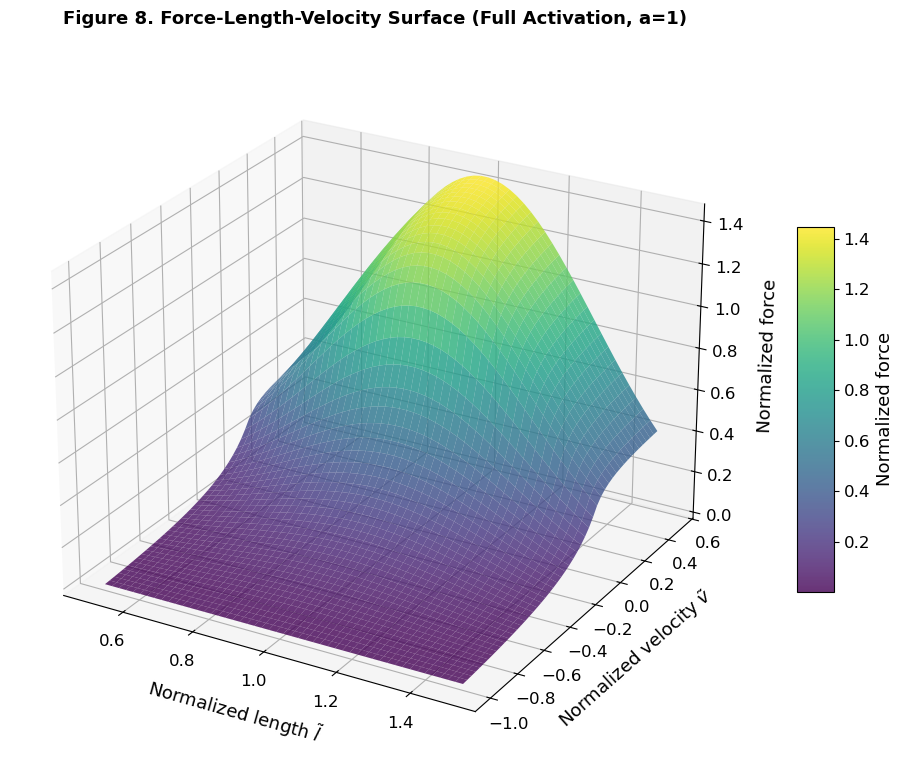

In [11]:
# --- Figure 8: 3D Force-Length-Velocity Surface ---

muscle = HillMuscleModel()

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

l_range = np.linspace(0.5, 1.5, 50)
v_range = np.linspace(-1.0, 0.5, 50)
L, V = np.meshgrid(l_range, v_range)

# Compute force surface (fully activated, a=1)
F_surface = np.zeros_like(L)
for i in range(L.shape[0]):
    for j in range(L.shape[1]):
        fl = muscle.force_length(L[i, j])
        fv = muscle.force_velocity(V[i, j])
        F_surface[i, j] = fl * fv

surf = ax.plot_surface(L, V, F_surface, cmap='viridis', alpha=0.8, edgecolor='none')

ax.set_xlabel('Normalized length $\\tilde{l}$', labelpad=10)
ax.set_ylabel('Normalized velocity $\\tilde{v}$', labelpad=10)
ax.set_zlabel('Normalized force', labelpad=10)
ax.set_title('Figure 8. Force-Length-Velocity Surface (Full Activation, a=1)',
             fontweight='bold', fontsize=13, pad=15)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Normalized force')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

### 9.1 Isometric Contraction Simulation

In an **isometric contraction**, the muscle length is held constant (velocity = 0) while activation increases. This is the simplest test of the model and mimics experiments where a muscle is stimulated while its tendons are fixed.

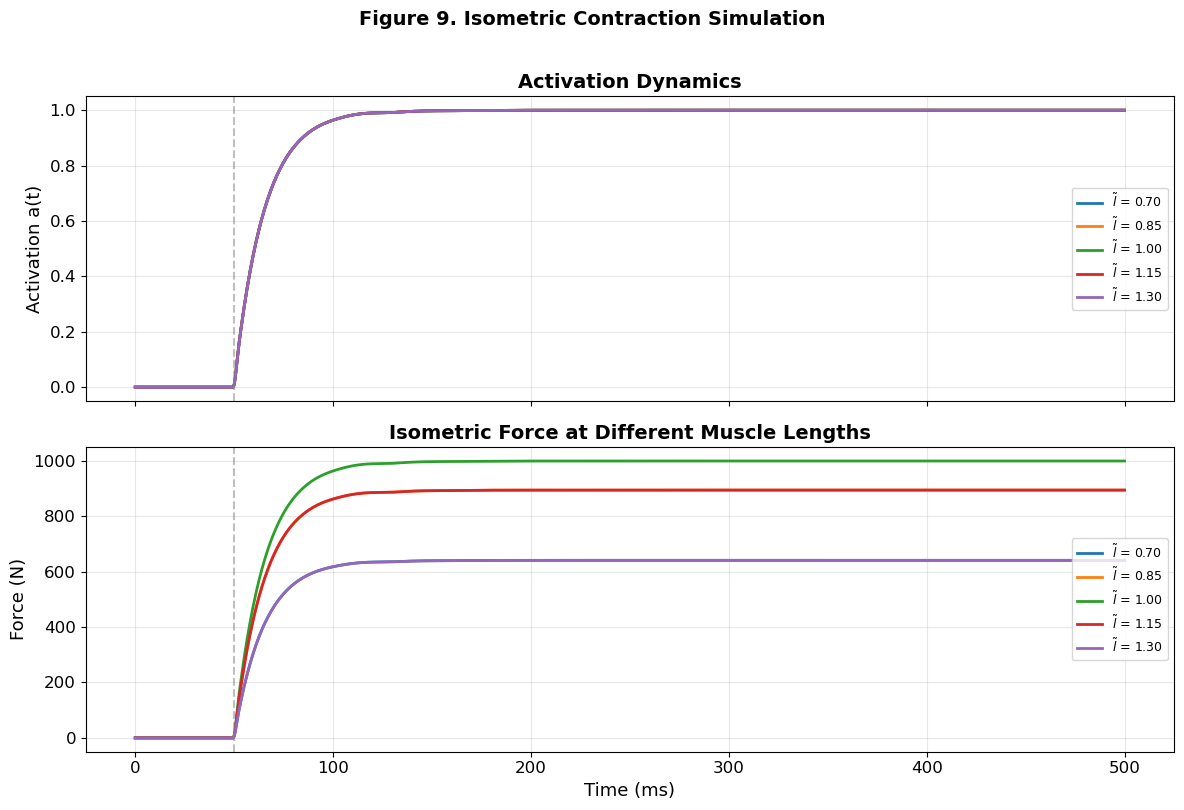

In [12]:
# --- Simulation 1: Isometric contraction at different lengths ---

muscle = HillMuscleModel(F0=1000.0)

t_span = (0, 0.5)  # 500 ms
t_eval = np.linspace(*t_span, 1000)

# Step input: excitation goes from 0 to 1 at t=50ms
def excitation(t):
    return 1.0 if t > 0.05 else 0.0

# Test at different normalized lengths
test_lengths = [0.7, 0.85, 1.0, 1.15, 1.3]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for l_norm in test_lengths:
    # Solve activation dynamics
    def ode_activation(t, y):
        a = y[0]
        u = excitation(t)
        dadt = muscle.activation_dynamics(a, u)
        return [dadt]
    
    sol = solve_ivp(ode_activation, t_span, [0.0], t_eval=t_eval, method='RK45')
    activation = sol.y[0]
    
    # Compute force (isometric: v=0)
    force = activation * muscle.F0 * muscle.force_length(l_norm)
    
    # Plot activation
    axes[0].plot(sol.t * 1000, activation, linewidth=2, label=f'$\\tilde{{l}}$ = {l_norm:.2f}')
    
    # Plot force
    axes[1].plot(sol.t * 1000, force, linewidth=2, label=f'$\\tilde{{l}}$ = {l_norm:.2f}')

axes[0].set_ylabel('Activation a(t)')
axes[0].set_title('Activation Dynamics', fontweight='bold')
axes[0].legend(loc='right', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='Stimulus onset')

axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Force (N)')
axes[1].set_title('Isometric Force at Different Muscle Lengths', fontweight='bold')
axes[1].legend(loc='right', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.5)

fig.suptitle('Figure 9. Isometric Contraction Simulation', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9.2 Motor Unit Pool Simulation

Now let's simulate a more realistic scenario: a pool of motor units with different sizes, thresholds, and fiber types, following Henneman's size principle.

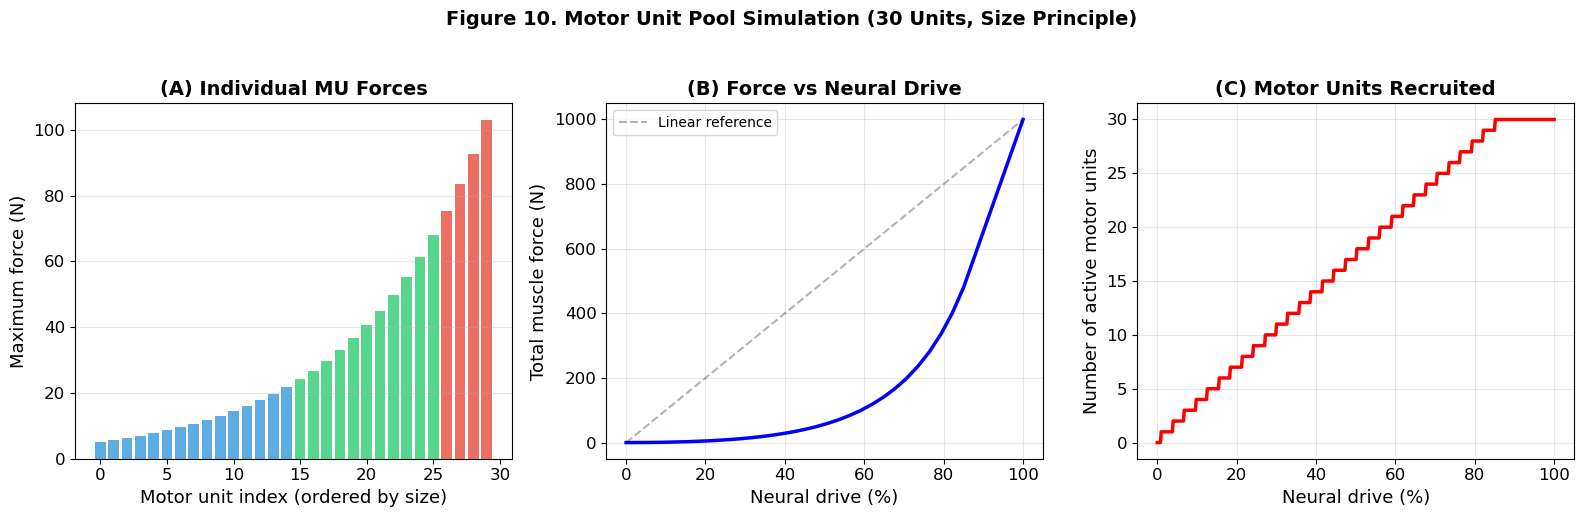

In [13]:
# --- Simulation 2: Motor Unit Pool with Size Principle ---

class MotorUnitPool:
    """
    A pool of motor units following Henneman's size principle.
    
    Parameters
    ----------
    n_units : int
        Number of motor units
    F0_total : float
        Total maximum isometric force (N)
    """
    
    def __init__(self, n_units=20, F0_total=1000.0):
        self.n_units = n_units
        self.F0_total = F0_total
        
        # Recruitment thresholds (ordered from low to high)
        self.thresholds = np.linspace(0.01, 0.85, n_units)
        
        # Motor unit forces (exponentially distributed — size principle)
        raw_forces = np.exp(np.linspace(0, 3, n_units))
        self.unit_forces = raw_forces / raw_forces.sum() * F0_total
        
        # Twitch durations (inverse of force — small units are slow)
        self.twitch_durations = np.linspace(0.08, 0.03, n_units)  # seconds
        
        # Fiber types
        self.fiber_types = []
        for i in range(n_units):
            if i < n_units * 0.5:
                self.fiber_types.append('Type I')
            elif i < n_units * 0.85:
                self.fiber_types.append('Type IIa')
            else:
                self.fiber_types.append('Type IIx')
    
    def get_active_force(self, excitation_level):
        """
        Compute total force for a given excitation level.
        
        Parameters
        ----------
        excitation_level : float or array
            Neural drive level in [0, 1]
        
        Returns
        -------
        total_force : float or array
            Total force from all recruited motor units
        n_active : int or array
            Number of active motor units
        """
        if np.isscalar(excitation_level):
            active = self.thresholds <= excitation_level
            # Rate coding: force increases with excitation above threshold
            gains = np.clip((excitation_level - self.thresholds) / (1.0 - self.thresholds + 1e-6), 0, 1)
            total_force = np.sum(self.unit_forces * gains * active)
            n_active = np.sum(active)
            return total_force, n_active
        
        forces = np.zeros_like(excitation_level)
        n_actives = np.zeros_like(excitation_level, dtype=int)
        for i, exc in enumerate(excitation_level):
            forces[i], n_actives[i] = self.get_active_force(exc)
        return forces, n_actives


# Create motor unit pool
pool = MotorUnitPool(n_units=30, F0_total=1000.0)

# Compute force across excitation levels
excitation_levels = np.linspace(0, 1.0, 500)
forces, n_active = pool.get_active_force(excitation_levels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Individual motor unit forces
ax = axes[0]
colors_type = {'Type I': '#3498db', 'Type IIa': '#2ecc71', 'Type IIx': '#e74c3c'}
bar_colors = [colors_type[ft] for ft in pool.fiber_types]
ax.bar(range(pool.n_units), pool.unit_forces, color=bar_colors, alpha=0.8)
ax.set_xlabel('Motor unit index (ordered by size)')
ax.set_ylabel('Maximum force (N)')
ax.set_title('(A) Individual MU Forces', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Panel B: Recruitment curve
ax = axes[1]
ax.plot(excitation_levels * 100, forces, 'b-', linewidth=2.5)
ax.set_xlabel('Neural drive (%)')
ax.set_ylabel('Total muscle force (N)')
ax.set_title('(B) Force vs Neural Drive', fontweight='bold')
ax.grid(True, alpha=0.3)

# Add nonlinearity annotation
ax.plot([0, 100], [0, 1000], 'k--', alpha=0.3, label='Linear reference')
ax.legend(fontsize=10)

# Panel C: Number of active motor units
ax = axes[2]
ax.plot(excitation_levels * 100, n_active, 'r-', linewidth=2.5)
ax.set_xlabel('Neural drive (%)')
ax.set_ylabel('Number of active motor units')
ax.set_title('(C) Motor Units Recruited', fontweight='bold')
ax.grid(True, alpha=0.3)

fig.suptitle('Figure 10. Motor Unit Pool Simulation (30 Units, Size Principle)',
             fontweight='bold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 9.3 Muscle Twitch and Tetanus Simulation

A single action potential in a motor neuron produces a **twitch** — a brief, small contraction. When action potentials arrive in rapid succession, the twitches **summate** and at high enough frequencies produce a smooth, sustained **tetanus** — the maximum force the motor unit can generate.

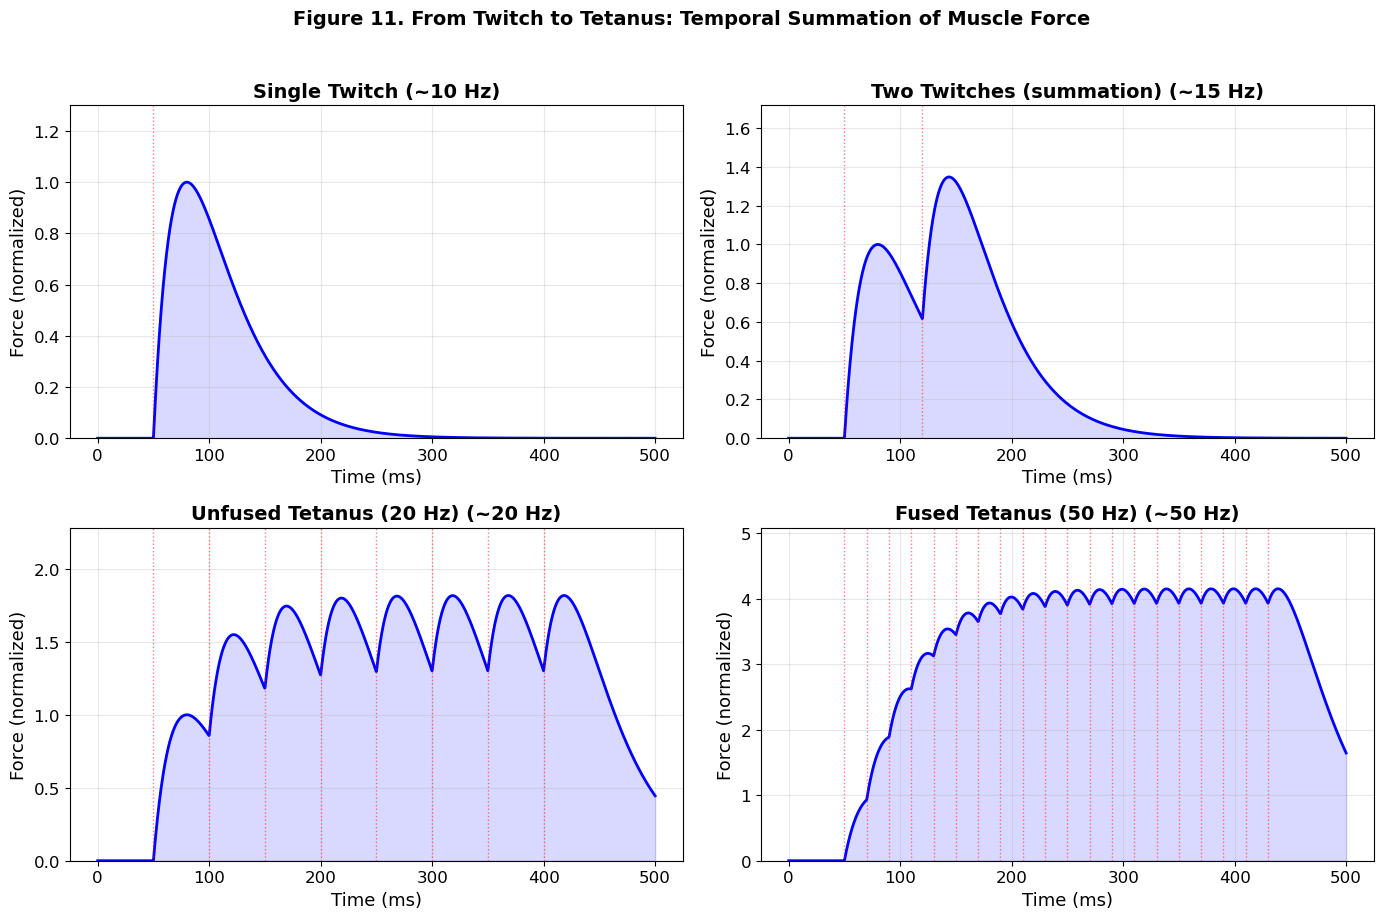

In [14]:
# --- Figure 11: Twitch summation and tetanus ---

def twitch_force(t, t_stim, peak_force=1.0, t_peak=0.03, t_decay=0.05):
    """Single twitch response to a stimulus at time t_stim."""
    dt = t - t_stim
    if dt < 0:
        return 0.0
    # Twitch modeled as gamma function
    return peak_force * (dt / t_peak) * np.exp(1 - dt / t_peak)

t = np.linspace(0, 0.5, 2000)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

scenarios = [
    ('Single Twitch', [0.05], 10),
    ('Two Twitches (summation)', [0.05, 0.12], 15),
    ('Unfused Tetanus (20 Hz)', np.arange(0.05, 0.45, 0.05), 20),
    ('Fused Tetanus (50 Hz)', np.arange(0.05, 0.45, 0.02), 50),
]

for ax, (title, stim_times, freq) in zip(axes.flat, scenarios):
    force = np.zeros_like(t)
    for t_stim in stim_times:
        for i, ti in enumerate(t):
            force[i] += twitch_force(ti, t_stim)
    
    ax.plot(t * 1000, force, 'b-', linewidth=2)
    ax.fill_between(t * 1000, 0, force, alpha=0.15, color='blue')
    
    # Mark stimulus times
    for t_stim in stim_times:
        ax.axvline(x=t_stim * 1000, color='red', linestyle=':', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Force (normalized)')
    ax.set_title(f'{title} (~{freq} Hz)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, max(force) * 1.2 + 0.1)

fig.suptitle('Figure 11. From Twitch to Tetanus: Temporal Summation of Muscle Force',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Check Your Understanding: Twitches and Tetanus

**Q7.** Why does fused tetanus produce a higher force than a single twitch, even though each stimulus activates the same number of cross-bridges?

<details>
<summary>Click to reveal answer</summary>

The key is **calcium concentration**. During a single twitch, Ca²⁺ is released and then quickly pumped back into the sarcoplasmic reticulum — the intracellular Ca²⁺ concentration rises and falls rapidly, and not all troponin binding sites are occupied simultaneously.

During tetanus, stimuli arrive so rapidly that Ca²⁺ accumulates in the cytoplasm (release exceeds reuptake), leading to:
1. **Higher sustained Ca²⁺ levels** → more troponin sites occupied → more cross-bridges active simultaneously
2. **Mechanical summation** — each new twitch adds force before the previous one has decayed
3. **Elastic element stretch** — the series elastic element (tendon) reaches a steady-state stretch, so more of the contractile force is transmitted externally

Tetanic force is typically **3–5 times** the twitch force.

</details>

---

**Q8.** A patient with myasthenia gravis has reduced neuromuscular transmission efficiency. How would the force-frequency curve be affected?

<details>
<summary>Click to reveal answer</summary>

In myasthenia gravis, antibodies block acetylcholine receptors at the neuromuscular junction. This means:
1. **Some stimuli fail** to produce action potentials in the muscle fiber → individual twitches may be absent
2. The effective stimulation frequency is **reduced** (not every nerve impulse reaches the muscle)
3. At moderate frequencies, the patient may have **unfused tetanus** where a healthy person would have fused tetanus
4. The maximum tetanic force is **reduced** because fewer fibers respond

The force-frequency curve shifts **rightward** (higher frequencies needed for tetanus) and **downward** (reduced maximum force). This explains the characteristic **fatigability** — force declines with repeated use as neuromuscular transmission failure worsens.

</details>

## 10. Muscle Fatigue Modeling

Real muscles fatigue — their force output declines with sustained or repeated contractions. Fatigue is a complex, multifactorial phenomenon involving both **central** (neural) and **peripheral** (muscular) mechanisms.

A simple phenomenological model captures the essential behavior:

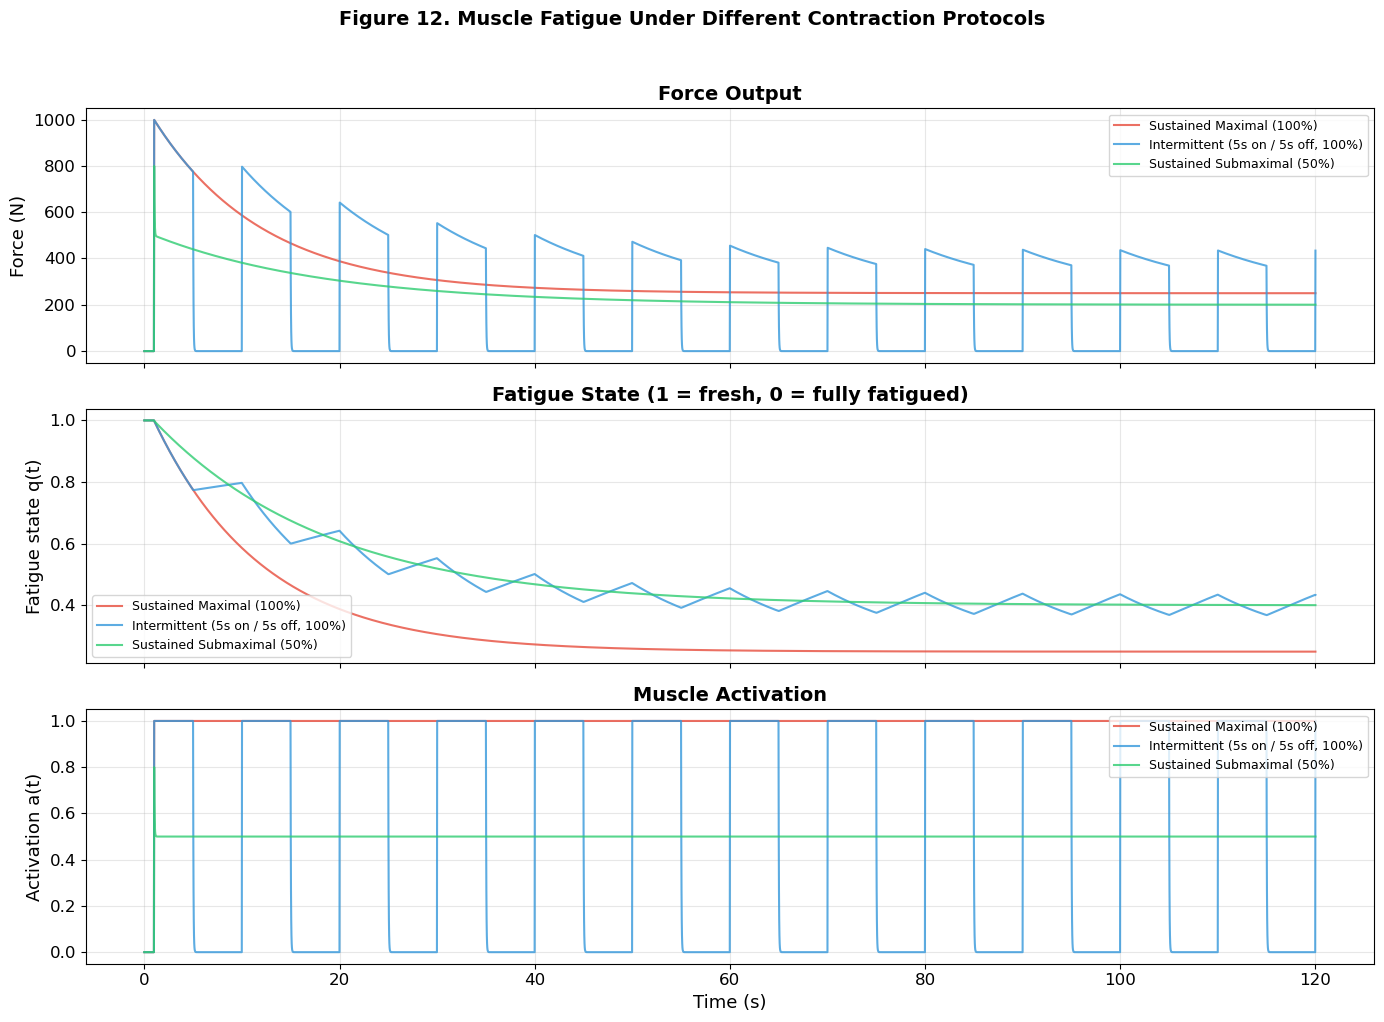

In [15]:
# --- Figure 12: Muscle fatigue simulation ---

def simulate_fatigue(t, excitation_profile, tau_fatigue=15.0, tau_recovery=45.0):
    """
    Simple fatigue model.
    
    Fatigue state q(t) ∈ [0, 1] represents the fraction of
    force-generating capacity remaining.
    
    dq/dt = (1 - q) / tau_recovery  -  a(t) * q / tau_fatigue
    
    Effective force = a(t) * q(t) * F0 * f_L * f_V
    """
    dt_sim = t[1] - t[0]
    q = np.ones_like(t)  # Fatigue state
    activation = np.zeros_like(t)
    force = np.zeros_like(t)
    
    muscle = HillMuscleModel(F0=1000.0)
    a = 0.0
    
    for i in range(1, len(t)):
        u = excitation_profile(t[i])
        
        # Activation dynamics
        da = muscle.activation_dynamics(a, u)
        a = a + da * dt_sim
        a = np.clip(a, 0, 1)
        activation[i] = a
        
        # Fatigue dynamics
        dq = (1 - q[i-1]) / tau_recovery - a * q[i-1] / tau_fatigue
        q[i] = q[i-1] + dq * dt_sim
        q[i] = np.clip(q[i], 0, 1)
        
        # Force (isometric at optimal length)
        force[i] = a * q[i] * muscle.F0
    
    return activation, q, force

# Simulate different contraction protocols
t = np.linspace(0, 120, 5000)  # 2 minutes

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Protocol 1: Sustained maximal contraction
def sustained_max(t):
    return 1.0 if t > 1.0 else 0.0

# Protocol 2: Intermittent (5s on, 5s off)
def intermittent(t):
    if t < 1.0:
        return 0.0
    return 1.0 if (t % 10) < 5 else 0.0

# Protocol 3: Submaximal (50%)
def submaximal(t):
    return 0.5 if t > 1.0 else 0.0

protocols = [
    ('Sustained Maximal (100%)', sustained_max, '#e74c3c'),
    ('Intermittent (5s on / 5s off, 100%)', intermittent, '#3498db'),
    ('Sustained Submaximal (50%)', submaximal, '#2ecc71'),
]

for ax_idx, (name, protocol, color) in enumerate(protocols):
    activation, q, force = simulate_fatigue(t, protocol)
    
    axes[0].plot(t, force, color=color, linewidth=1.5, label=name, alpha=0.8)
    axes[1].plot(t, q, color=color, linewidth=1.5, label=name, alpha=0.8)
    axes[2].plot(t, activation, color=color, linewidth=1.5, label=name, alpha=0.8)

axes[0].set_ylabel('Force (N)')
axes[0].set_title('Force Output', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Fatigue state q(t)')
axes[1].set_title('Fatigue State (1 = fresh, 0 = fully fatigued)', fontweight='bold')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Activation a(t)')
axes[2].set_title('Muscle Activation', fontweight='bold')
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)

fig.suptitle('Figure 12. Muscle Fatigue Under Different Contraction Protocols',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Motor Control: From Neural Command to Movement

### The motor control hierarchy

Movement is controlled by a hierarchy of neural structures:

| Level | Structure | Function | Timescale |
|-------|-----------|----------|-----------|
| **Cortical** | Motor cortex, premotor cortex, SMA | Movement planning, voluntary commands | 100–500 ms |
| **Subcortical** | Basal ganglia, cerebellum | Action selection, error correction, timing | 50–200 ms |
| **Brainstem** | Reticular formation, vestibular nuclei | Posture, balance, locomotion patterns | 20–100 ms |
| **Spinal** | Motor neurons, interneurons, CPGs | Motor unit recruitment, reflexes, rhythmic patterns | 1–50 ms |
| **Peripheral** | Muscles, tendons, joints | Force generation, mechanical compliance | 10–100 ms |

### Computational models of motor control

Modern theories of motor control are fundamentally computational:

1. **Internal models**: The brain maintains "forward models" (predict sensory consequences of actions) and "inverse models" (compute motor commands for desired outcomes)
2. **Optimal control**: Movements minimize a cost function (e.g. effort, jerk, endpoint variance)
3. **Feedback control**: Sensory feedback (proprioception, vision) is used to correct errors online
4. **Central Pattern Generators (CPGs)**: Spinal circuits generate rhythmic motor patterns (e.g. walking) without continuous cortical input

Let's simulate a simple but instructive example: **controlling a single-joint limb with an agonist-antagonist muscle pair**.

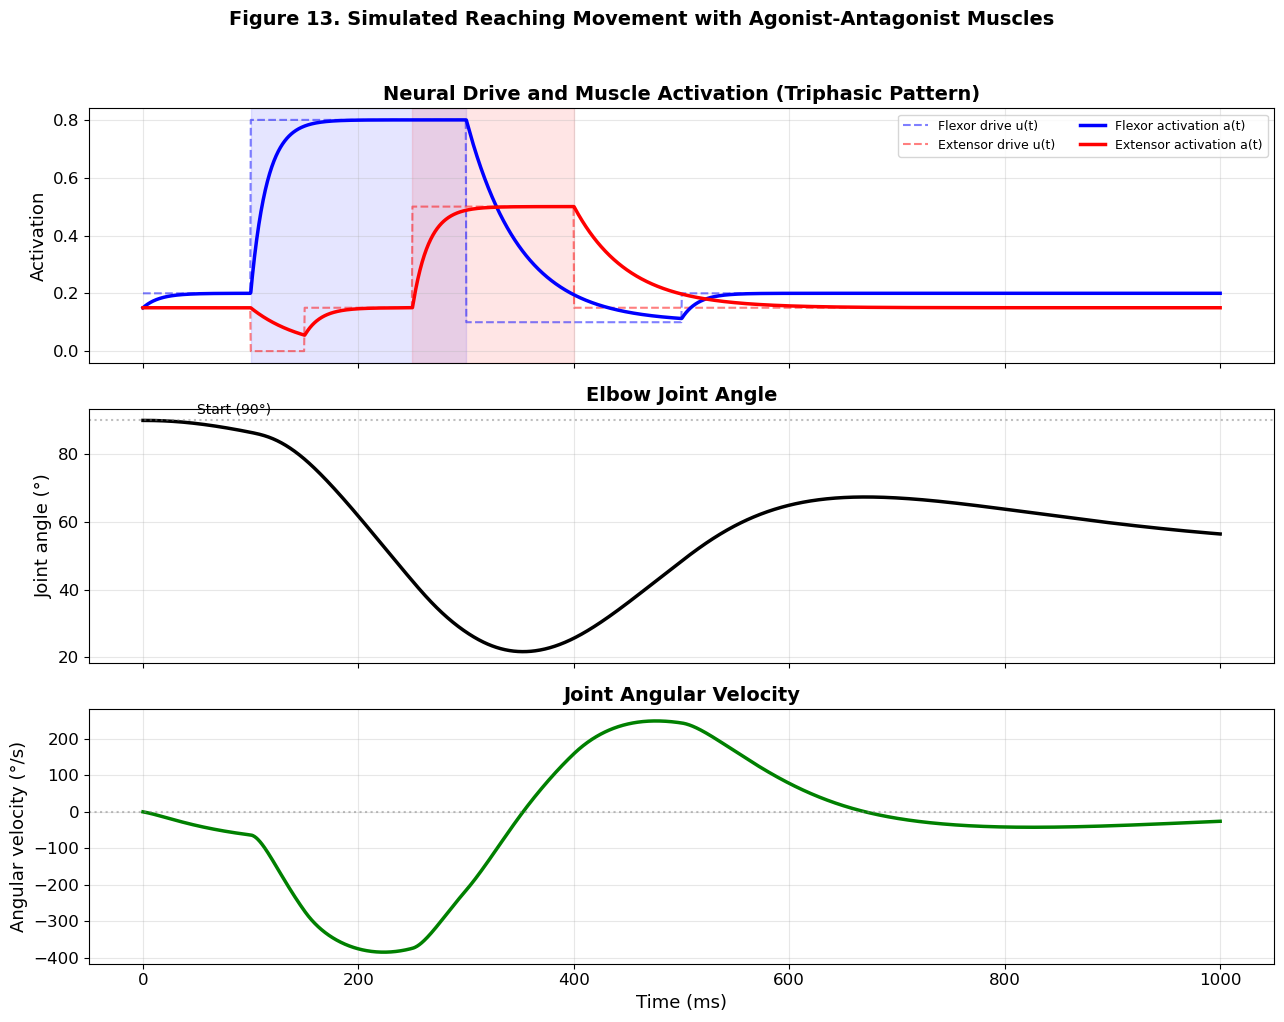

In [16]:
# --- Simulation 3: Single-joint movement with agonist-antagonist muscles ---

class SingleJointArm:
    """
    Simple single-joint (elbow) model with agonist-antagonist muscles.
    
    Models the elbow joint as a hinge controlled by a flexor (biceps)
    and extensor (triceps) muscle, each modeled as Hill-type muscles.
    """
    
    def __init__(self):
        # Limb parameters
        self.I = 0.1       # Moment of inertia (kg·m²)
        self.b_damp = 0.5  # Viscous damping (N·m·s/rad)
        self.r = 0.03      # Moment arm (m)
        
        # Muscles
        self.flexor = HillMuscleModel(F0=800, l_opt=0.12, v_max=10)
        self.extensor = HillMuscleModel(F0=600, l_opt=0.12, v_max=10)
        
        # Rest angle
        self.theta_rest = np.pi / 2  # 90 degrees
    
    def muscle_length_norm(self, theta, is_flexor=True):
        """Normalized muscle length as function of joint angle."""
        if is_flexor:
            return 1.0 + (theta - self.theta_rest) * self.r / self.flexor.l_opt
        else:
            return 1.0 - (theta - self.theta_rest) * self.r / self.extensor.l_opt
    
    def dynamics(self, t, state, u_flexor_func, u_extensor_func):
        """
        Equations of motion.
        
        state = [theta, omega, a_flex, a_ext]
        """
        theta, omega, a_flex, a_ext = state
        
        # Neural inputs
        u_flex = u_flexor_func(t)
        u_ext = u_extensor_func(t)
        
        # Activation dynamics
        da_flex = self.flexor.activation_dynamics(a_flex, u_flex)
        da_ext = self.extensor.activation_dynamics(a_ext, u_ext)
        
        # Muscle lengths and velocities
        l_flex = self.muscle_length_norm(theta, True)
        l_ext = self.muscle_length_norm(theta, False)
        v_flex = omega * self.r / self.flexor.l_opt / self.flexor.v_max
        v_ext = -omega * self.r / self.extensor.l_opt / self.extensor.v_max
        
        # Muscle forces
        F_flex = self.flexor.total_force(a_flex, l_flex, v_flex)
        F_ext = self.extensor.total_force(a_ext, l_ext, v_ext)
        
        # Joint torques
        tau_flex = -F_flex * self.r  # Flexor creates negative (flexion) torque
        tau_ext = F_ext * self.r     # Extensor creates positive (extension) torque
        tau_damp = -self.b_damp * omega
        
        # Equations of motion: I * alpha = sum(torques)
        alpha = (tau_flex + tau_ext + tau_damp) / self.I
        
        return [omega, alpha, da_flex, da_ext]


# Create arm model
arm = SingleJointArm()

# Define movement: reach from 90° to 45° (flexion)
def u_flexor(t):
    """Flexor excitation: pulse for reaching movement."""
    if 0.1 < t < 0.3:
        return 0.8  # Agonist burst
    elif 0.3 < t < 0.5:
        return 0.1  # Low tonic
    else:
        return 0.2  # Holding

def u_extensor(t):
    """Extensor excitation: triphasic pattern."""
    if 0.1 < t < 0.15:
        return 0.0  # Release (reciprocal inhibition)
    elif 0.25 < t < 0.4:
        return 0.5  # Antagonist brake
    else:
        return 0.15  # Tonic

# Simulate
t_span = (0, 1.0)
t_eval = np.linspace(*t_span, 2000)
y0 = [np.pi/2, 0, 0.15, 0.15]  # [theta, omega, a_flex, a_ext]

sol = solve_ivp(
    lambda t, y: arm.dynamics(t, y, u_flexor, u_extensor),
    t_span, y0, t_eval=t_eval, method='RK45', max_step=0.001
)

theta = np.degrees(sol.y[0])
omega = np.degrees(sol.y[1])
a_flex = sol.y[2]
a_ext = sol.y[3]

# Neural drive signals
u_f = np.array([u_flexor(t) for t in sol.t])
u_e = np.array([u_extensor(t) for t in sol.t])

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel 1: Neural drive and activation
ax = axes[0]
ax.plot(sol.t * 1000, u_f, 'b--', linewidth=1.5, alpha=0.5, label='Flexor drive u(t)')
ax.plot(sol.t * 1000, u_e, 'r--', linewidth=1.5, alpha=0.5, label='Extensor drive u(t)')
ax.plot(sol.t * 1000, a_flex, 'b-', linewidth=2.5, label='Flexor activation a(t)')
ax.plot(sol.t * 1000, a_ext, 'r-', linewidth=2.5, label='Extensor activation a(t)')
ax.set_ylabel('Activation')
ax.set_title('Neural Drive and Muscle Activation (Triphasic Pattern)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.axvspan(100, 300, alpha=0.1, color='blue', label='Agonist burst')
ax.axvspan(250, 400, alpha=0.1, color='red', label='Antagonist brake')

# Panel 2: Joint angle
ax = axes[1]
ax.plot(sol.t * 1000, theta, 'k-', linewidth=2.5)
ax.set_ylabel('Joint angle (°)')
ax.set_title('Elbow Joint Angle', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=90, color='gray', linestyle=':', alpha=0.5)
ax.annotate('Start (90°)', xy=(0, 90), xytext=(50, 92), fontsize=10)

# Panel 3: Angular velocity
ax = axes[2]
ax.plot(sol.t * 1000, omega, 'g-', linewidth=2.5)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Angular velocity (°/s)')
ax.set_title('Joint Angular Velocity', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

fig.suptitle('Figure 13. Simulated Reaching Movement with Agonist-Antagonist Muscles',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### The triphasic EMG pattern

The simulation above demonstrates a fundamental finding in motor control research: fast point-to-point movements are controlled by a **triphasic EMG pattern**:

1. **Agonist burst (AG1)**: The prime mover (flexor) fires a strong burst to accelerate the limb toward the target
2. **Antagonist burst (ANT)**: The opposing muscle (extensor) fires to decelerate the limb and prevent overshoot
3. **Second agonist burst (AG2)**: A smaller agonist burst for final positioning and stabilization

This pattern is remarkably consistent across different movements, muscles, and species — suggesting it reflects a fundamental control strategy of the nervous system. It is also a key challenge in robotics: replicating this pattern with artificial actuators.

> *The triphasic pattern is thought to be programmed by the central nervous system as a "motor program" — a pre-planned sequence that can be executed without relying on slow sensory feedback for the initial phases of rapid movement.*

## 12. From Humans to Robots: Bioinspired Motor Control

### Why robots need muscle-like actuators

Conventional robots use stiff, high-precision electric motors or hydraulic actuators. While excellent for industrial tasks, they struggle with:
- **Safety** around humans (rigid collisions cause injury)
- **Compliance** when interacting with soft, deformable objects
- **Energy efficiency** in dynamic tasks (walking, running)
- **Robustness** to unexpected perturbations

Biological muscles, by contrast, are inherently:
- **Compliant** — the force-length and force-velocity relationships provide natural "impedance"
- **Adaptive** — activation can be modulated continuously
- **Efficient** — elastic energy storage in tendons reduces metabolic cost
- **Robust** — redundant motor units provide graceful degradation

### Series Elastic Actuators (SEAs)

Inspired by the muscle-tendon unit, **Series Elastic Actuators** (SEAs) add a compliant element (spring) in series with a stiff motor. This mimics the role of the tendon and provides:
- Shock absorption
- Accurate force sensing (by measuring spring deflection)
- Energy storage and release (like the Achilles tendon during running)
- Safer human-robot interaction

SEAs are used in many modern humanoid robots, prosthetics, and exoskeletons.

### Comparison: Biological muscle vs. robotic actuators

| Property | Skeletal Muscle | DC Motor | SEA | Pneumatic Artificial Muscle |
|----------|----------------|----------|-----|----------------------------|
| **Compliance** | Intrinsic (F-L, F-V) | None (rigid) | Series spring | Intrinsic (pressure-volume) |
| **Force control** | Via recruitment + rate coding | Via current | Via spring deflection | Via pressure |
| **Power/weight** | ~100–300 W/kg | ~100–500 W/kg | ~50–200 W/kg | ~1000+ W/kg |
| **Bandwidth** | 5–50 Hz | 100+ Hz | 10–50 Hz | 5–20 Hz |
| **Self-repair** | Yes | No | No | No |
| **Energy storage** | Tendon elasticity | None | Spring | Minimal |

Let's simulate a simple robot arm using both rigid and compliant (muscle-like) control to see the difference.

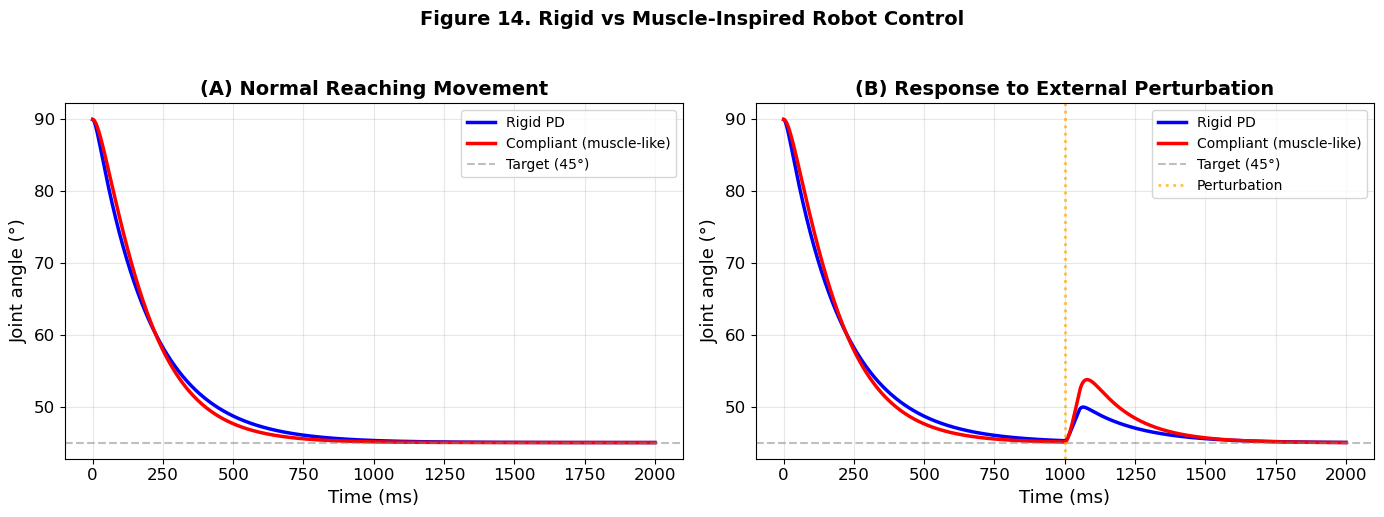

In [17]:
# --- Figure 14: Robot arm - rigid vs compliant control ---

class RobotArm:
    """Simple 1-DOF robot arm comparing rigid and compliant control."""
    
    def __init__(self, I=0.1, b=0.3):
        self.I = I      # Moment of inertia
        self.b = b      # Damping
    
    def rigid_pd_control(self, t, state, theta_target, Kp=50, Kd=10):
        """Standard PD controller (stiff motor)."""
        theta, omega = state
        tau = Kp * (theta_target - theta) + Kd * (0 - omega)
        alpha = (tau - self.b * omega) / self.I
        return [omega, alpha]
    
    def compliant_control(self, t, state, theta_target, K_spring=30, Kd=5):
        """Series elastic actuator (muscle-inspired) control."""
        theta, omega = state
        # Nonlinear spring (mimicking force-length curve)
        error = theta_target - theta
        tau = K_spring * error * np.exp(-0.5 * error**2) + Kd * (0 - omega)
        alpha = (tau - self.b * omega) / self.I
        return [omega, alpha]

robot = RobotArm()
t_span = (0, 2.0)
t_eval = np.linspace(*t_span, 2000)

theta_target = np.pi / 4  # Target: 45°
y0 = [np.pi / 2, 0]       # Start at 90°

# Simulate both controllers
sol_rigid = solve_ivp(
    lambda t, y: robot.rigid_pd_control(t, y, theta_target),
    t_span, y0, t_eval=t_eval, method='RK45'
)

sol_compliant = solve_ivp(
    lambda t, y: robot.compliant_control(t, y, theta_target),
    t_span, y0, t_eval=t_eval, method='RK45'
)

# Simulate perturbation scenario
def rigid_with_perturbation(t, state):
    theta, omega = state
    tau = 50 * (theta_target - theta) + 10 * (0 - omega)
    # External perturbation at t=1.0
    if 1.0 < t < 1.05:
        tau += 20  # Sudden push
    alpha = (tau - robot.b * omega) / robot.I
    return [omega, alpha]

def compliant_with_perturbation(t, state):
    theta, omega = state
    error = theta_target - theta
    tau = 30 * error * np.exp(-0.5 * error**2) + 5 * (0 - omega)
    if 1.0 < t < 1.05:
        tau += 20  # Same perturbation
    alpha = (tau - robot.b * omega) / robot.I
    return [omega, alpha]

sol_rigid_pert = solve_ivp(
    rigid_with_perturbation, t_span, y0, t_eval=t_eval, method='RK45'
)
sol_compliant_pert = solve_ivp(
    compliant_with_perturbation, t_span, y0, t_eval=t_eval, method='RK45'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Normal reaching
ax = axes[0]
ax.plot(sol_rigid.t * 1000, np.degrees(sol_rigid.y[0]), 'b-', linewidth=2.5, label='Rigid PD')
ax.plot(sol_compliant.t * 1000, np.degrees(sol_compliant.y[0]), 'r-', linewidth=2.5, label='Compliant (muscle-like)')
ax.axhline(y=np.degrees(theta_target), color='gray', linestyle='--', alpha=0.5, label='Target (45°)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Joint angle (°)')
ax.set_title('(A) Normal Reaching Movement', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel B: Response to perturbation
ax = axes[1]
ax.plot(sol_rigid_pert.t * 1000, np.degrees(sol_rigid_pert.y[0]), 'b-', linewidth=2.5, label='Rigid PD')
ax.plot(sol_compliant_pert.t * 1000, np.degrees(sol_compliant_pert.y[0]), 'r-', linewidth=2.5, label='Compliant (muscle-like)')
ax.axhline(y=np.degrees(theta_target), color='gray', linestyle='--', alpha=0.5, label='Target (45°)')
ax.axvline(x=1000, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='Perturbation')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Joint angle (°)')
ax.set_title('(B) Response to External Perturbation', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('Figure 14. Rigid vs Muscle-Inspired Robot Control',
             fontweight='bold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

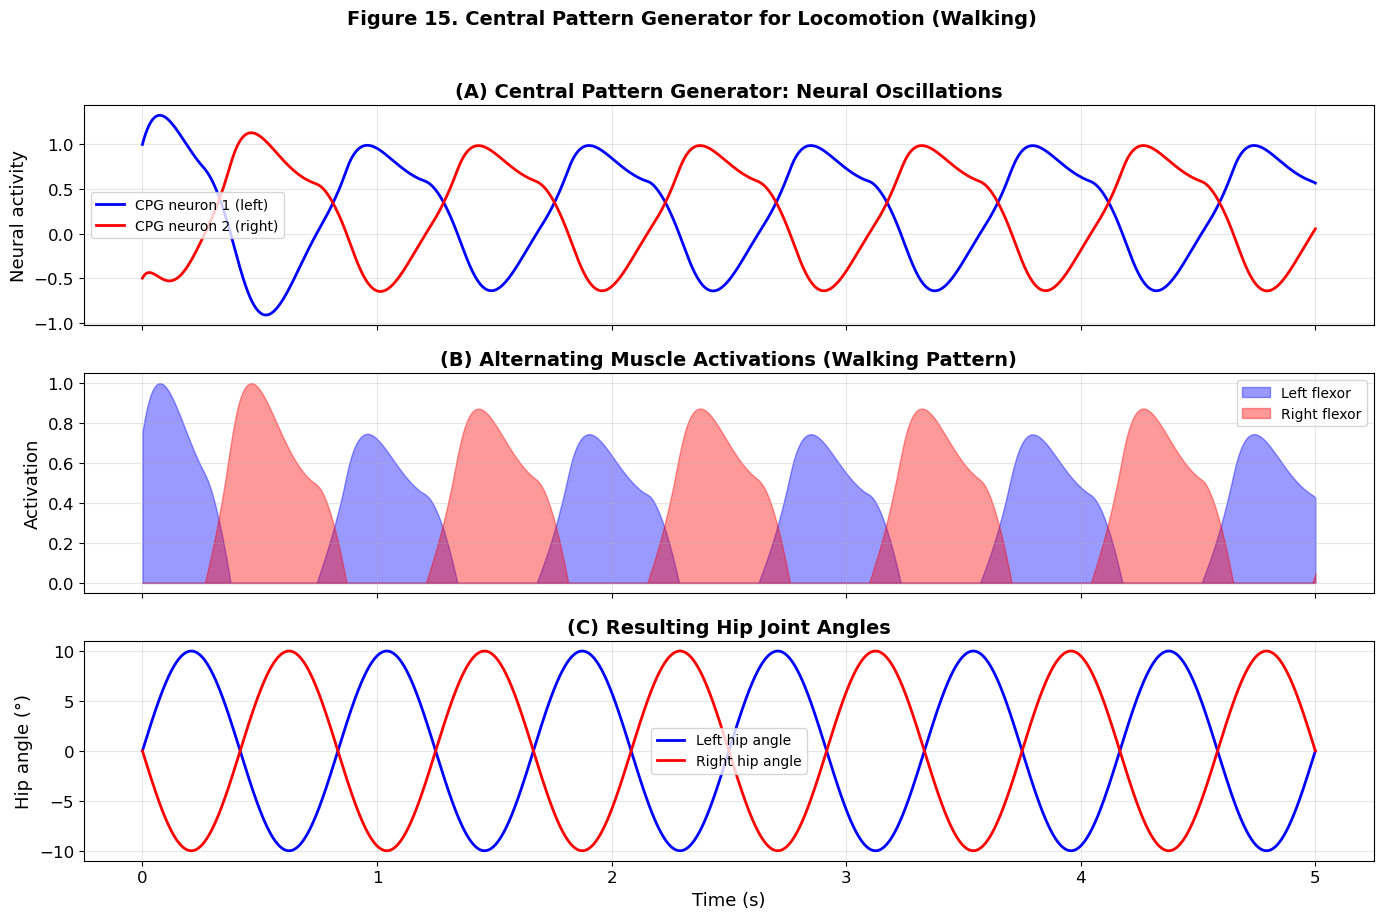

In [18]:
# --- Figure 15: Walking CPG simulation ---

def cpg_oscillator(t, state, omega=2*np.pi*1.2, coupling=2.0):
    """
    Simple Central Pattern Generator (CPG) model.
    Two coupled oscillators producing alternating left-right activation
    for walking pattern generation.
    
    Based on Matsuoka (1985) half-center oscillator.
    """
    x1, x2, y1, y2 = state
    
    tau = 0.1  # Time constant
    beta = 2.5  # Adaptation rate
    tonic = 2.0  # Tonic drive
    
    # Neuron outputs (rectified)
    out1 = max(0, x1)
    out2 = max(0, x2)
    
    # Dynamics (mutually inhibitory half-centers)
    dx1 = (-x1 - coupling * out2 - beta * y1 + tonic) / tau
    dx2 = (-x2 - coupling * out1 - beta * y2 + tonic) / tau
    dy1 = (-y1 + out1) / (tau * 3)
    dy2 = (-y2 + out2) / (tau * 3)
    
    return [dx1, dx2, dy1, dy2]

# Simulate CPG
t_span_cpg = (0, 5)
t_eval_cpg = np.linspace(*t_span_cpg, 5000)
y0_cpg = [1.0, -0.5, 0.0, 0.0]

sol_cpg = solve_ivp(cpg_oscillator, t_span_cpg, y0_cpg, t_eval=t_eval_cpg, method='RK45')

# Convert to muscle activations
left_flexor = np.maximum(0, sol_cpg.y[0])
right_flexor = np.maximum(0, sol_cpg.y[1])
left_extensor = np.maximum(0, -sol_cpg.y[0] * 0.5 + 0.3)
right_extensor = np.maximum(0, -sol_cpg.y[1] * 0.5 + 0.3)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Panel A: CPG neuron outputs
ax = axes[0]
ax.plot(sol_cpg.t, sol_cpg.y[0], 'b-', linewidth=2, label='CPG neuron 1 (left)')
ax.plot(sol_cpg.t, sol_cpg.y[1], 'r-', linewidth=2, label='CPG neuron 2 (right)')
ax.set_ylabel('Neural activity')
ax.set_title('(A) Central Pattern Generator: Neural Oscillations', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel B: Muscle activations
ax = axes[1]
ax.fill_between(sol_cpg.t, 0, left_flexor / left_flexor.max(), alpha=0.4, color='blue', label='Left flexor')
ax.fill_between(sol_cpg.t, 0, right_flexor / right_flexor.max(), alpha=0.4, color='red', label='Right flexor')
ax.set_ylabel('Activation')
ax.set_title('(B) Alternating Muscle Activations (Walking Pattern)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel C: Simulated leg angles
ax = axes[2]
# Simple kinematic model: angle = integral of activation difference
left_angle = 10 * np.sin(2 * np.pi * 1.2 * sol_cpg.t)
right_angle = 10 * np.sin(2 * np.pi * 1.2 * sol_cpg.t + np.pi)
ax.plot(sol_cpg.t, left_angle, 'b-', linewidth=2, label='Left hip angle')
ax.plot(sol_cpg.t, right_angle, 'r-', linewidth=2, label='Right hip angle')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Hip angle (°)')
ax.set_title('(C) Resulting Hip Joint Angles', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('Figure 15. Central Pattern Generator for Locomotion (Walking)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### DIY Exercise: Explore the Simulations

**Exercise 3.** In the single-joint reaching simulation (Figure 13), what happens if you remove the antagonist brake entirely (set `u_extensor` to 0 during the movement)? Predict first, then modify the code.

<details>
<summary>Click to reveal answer</summary>

Without the antagonist brake, the limb will **overshoot** the target significantly and then oscillate back and forth before settling. This is because:
1. Nothing decelerates the limb as it approaches the target
2. Only passive damping slows the movement
3. The limb overshoots, then the flexor must re-activate to pull it back

This demonstrates why the triphasic pattern is essential for fast, accurate movements. Patients with cerebellar damage often show exactly this kind of **dysmetria** (overshooting or undershooting targets) because the cerebellum is crucial for timing the antagonist brake.

</details>

---

**Exercise 4.** In the CPG simulation (Figure 15), what would happen if the mutual inhibition coupling strength is reduced to near zero? What does this model in terms of pathology?

<details>
<summary>Click to reveal answer</summary>

With reduced coupling:
1. The two oscillators would lose their anti-phase relationship
2. They might synchronize (both legs flexing at the same time) or drift independently
3. The alternating walking pattern would break down

This models aspects of **spinal cord injury** or certain neurological conditions:
- After incomplete spinal cord injury, the CPG circuitry is partially disrupted
- Patients may show **co-activation** of flexors and extensors (spasticity)
- The normal alternating gait pattern is lost
- Rehabilitation strategies (e.g. treadmill training with body weight support) aim to "retrain" the CPG circuitry through repetitive activation of the spinal pattern generators

You can test this by changing `coupling=2.0` to `coupling=0.1` in the `cpg_oscillator` function.

</details>

---

**Exercise 5.** The robot comparison (Figure 14) shows that compliant control is more robust to perturbations. Can you think of a scenario where rigid control would be *preferable* to compliant control?

<details>
<summary>Click to reveal answer</summary>

Rigid control is preferable when:
1. **Precision is critical and perturbations are negligible** — e.g. surgical robots, CNC machining, semiconductor manufacturing
2. **Speed is paramount** — stiff actuators can achieve faster movements because they don't waste energy deforming a compliant element
3. **Heavy loads must be held statically** — a stiff system holds position without continuous energy expenditure in the spring
4. **The environment is well-known and controlled** — industrial robots on assembly lines operate in predictable environments

The key insight is that **muscles evolved for uncertain, dynamic environments** (the real world), while industrial robots often operate in **controlled, predictable environments**. The "right" actuation strategy depends on the task requirements.

This is why modern collaborative robots (cobots) use compliant control when interacting with humans but can switch to stiffer control for precision tasks.

</details>

## 13. Putting It All Together: EMG-Driven Muscle Simulation

In clinical and research settings, we often record **electromyography (EMG)** signals — the electrical activity of muscles — and use computational models to estimate the forces those muscles produce. This is called **EMG-driven musculoskeletal modeling**.

Let's simulate a realistic scenario: processing a synthetic EMG signal through the full Hill-type model pipeline.

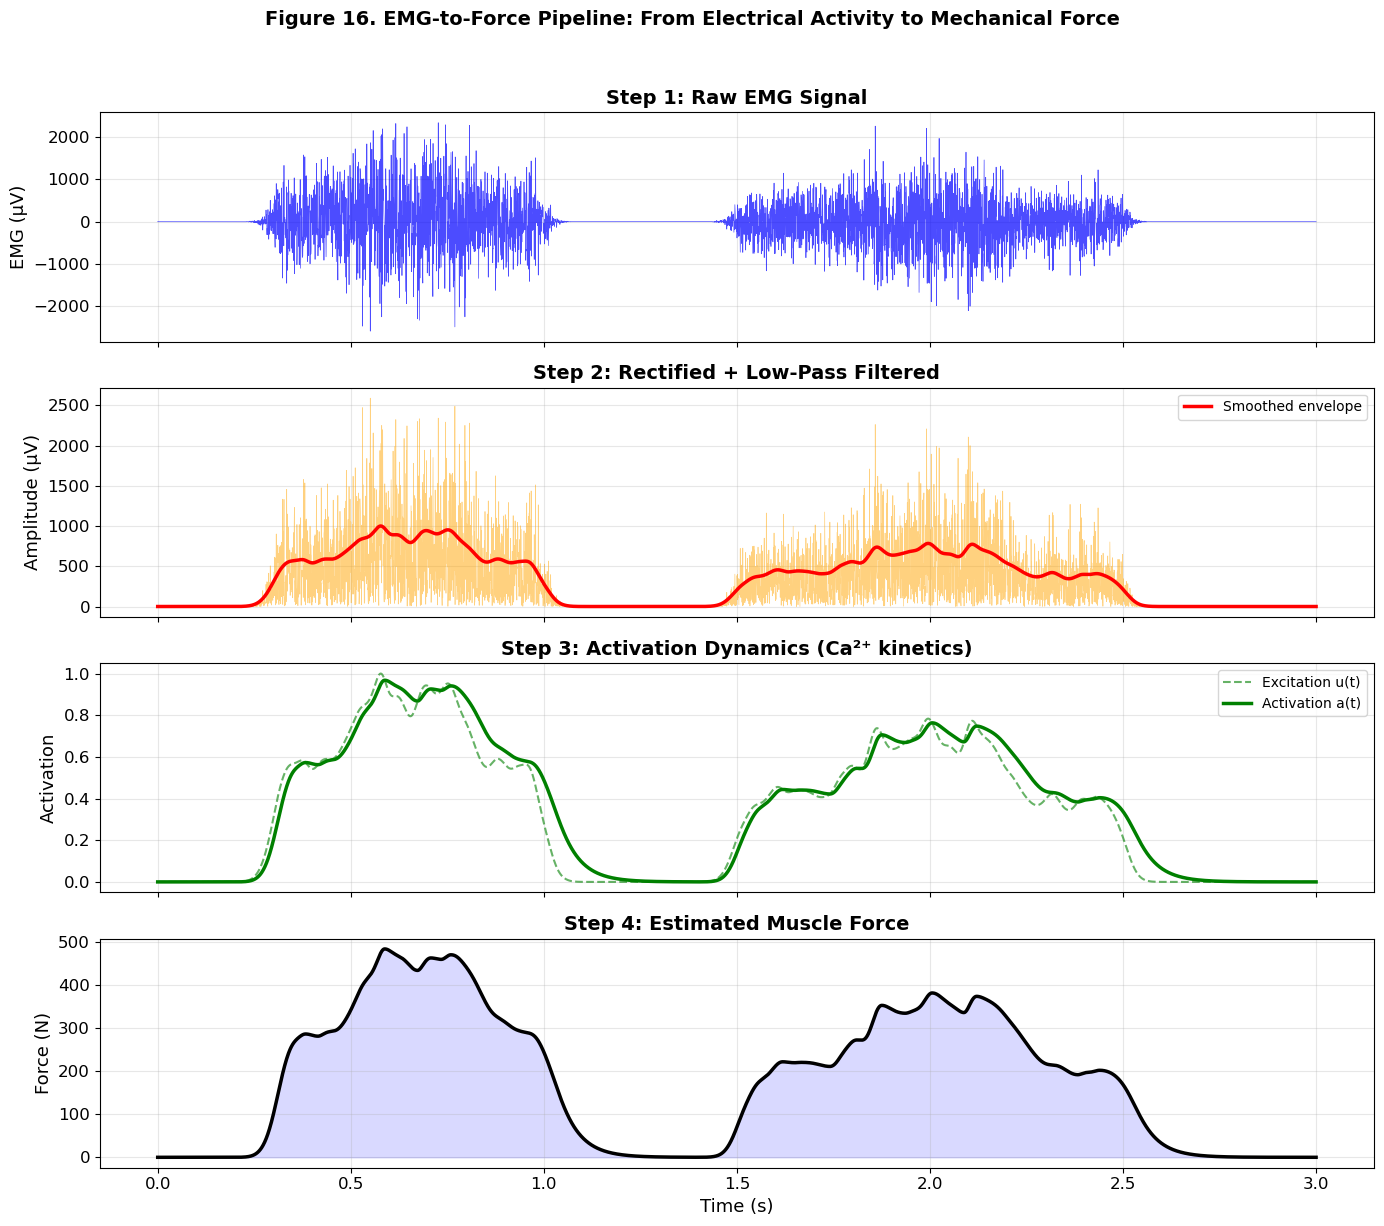

In [19]:
# --- Figure 16: EMG-driven force estimation pipeline ---

np.random.seed(42)

# Generate synthetic EMG signal
t_emg = np.linspace(0, 3.0, 6000)
dt = t_emg[1] - t_emg[0]

# Underlying activation pattern (two contractions)
envelope = np.zeros_like(t_emg)
envelope[(t_emg > 0.3) & (t_emg < 1.0)] = 0.6  # Moderate contraction
envelope[(t_emg > 0.5) & (t_emg < 0.8)] = 0.9   # Peak
envelope[(t_emg > 1.5) & (t_emg < 2.5)] = 0.4   # Lighter contraction
envelope[(t_emg > 1.8) & (t_emg < 2.2)] = 0.7   # Peak

# Smooth the envelope
from scipy.ndimage import gaussian_filter1d
envelope = gaussian_filter1d(envelope, sigma=50)

# Raw EMG = envelope × noise (simulating motor unit firing)
raw_emg = envelope * np.random.randn(len(t_emg))

# EMG processing pipeline
# Step 1: Full-wave rectification
rectified_emg = np.abs(raw_emg)

# Step 2: Low-pass filter (extract envelope)
processed_emg = gaussian_filter1d(rectified_emg, sigma=30)
processed_emg = processed_emg / (processed_emg.max() + 1e-6)  # Normalize to [0, 1]

# Step 3: Activation dynamics
muscle_emg = HillMuscleModel(F0=500.0)
activation_emg = np.zeros_like(t_emg)
a = 0.0
for i in range(1, len(t_emg)):
    u = processed_emg[i]
    da = muscle_emg.activation_dynamics(a, u)
    a = a + da * dt
    a = np.clip(a, 0, 1)
    activation_emg[i] = a

# Step 4: Force estimation (isometric at optimal length)
estimated_force = activation_emg * muscle_emg.F0

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t_emg, raw_emg * 1000, 'b-', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('EMG (μV)')
axes[0].set_title('Step 1: Raw EMG Signal', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_emg, rectified_emg * 1000, color='orange', linewidth=0.5, alpha=0.5)
axes[1].plot(t_emg, processed_emg * processed_emg.max() * 1000, 'r-', linewidth=2.5, label='Smoothed envelope')
axes[1].set_ylabel('Amplitude (μV)')
axes[1].set_title('Step 2: Rectified + Low-Pass Filtered', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_emg, processed_emg, 'g--', linewidth=1.5, alpha=0.6, label='Excitation u(t)')
axes[2].plot(t_emg, activation_emg, 'g-', linewidth=2.5, label='Activation a(t)')
axes[2].set_ylabel('Activation')
axes[2].set_title('Step 3: Activation Dynamics (Ca²⁺ kinetics)', fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_emg, estimated_force, 'k-', linewidth=2.5)
axes[3].fill_between(t_emg, 0, estimated_force, alpha=0.15, color='blue')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Force (N)')
axes[3].set_title('Step 4: Estimated Muscle Force', fontweight='bold')
axes[3].grid(True, alpha=0.3)

fig.suptitle('Figure 16. EMG-to-Force Pipeline: From Electrical Activity to Mechanical Force',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Summary and Key Concepts

### What we've covered

| Topic | Key Insight |
|-------|-------------|
| **Sliding filament theory** | Contraction = filaments sliding past each other, not shortening |
| **Cross-bridge cycle** | Molecular motor powered by ATP hydrolysis (~5 nm, ~3 pN per stroke) |
| **Force-length relationship** | Optimal length for maximum force (determined by filament overlap) |
| **Force-velocity relationship** | Faster shortening → less force (Hill's hyperbolic equation, 1938) |
| **Activation dynamics** | Ca²⁺ kinetics cause asymmetric activation/deactivation |
| **Hill muscle model** | CE + PEE + SEE = tractable model for simulation |
| **Motor unit recruitment** | Size principle (Henneman): small → large, orderly |
| **Rate coding** | Higher firing rates → more force (temporal summation → tetanus) |
| **Triphasic pattern** | AG1-ANT-AG2 for fast, accurate point-to-point movements |
| **Central Pattern Generators** | Spinal circuits for rhythmic movements (walking) |
| **Fatigue** | Progressive force decline from metabolic and neural factors |
| **Bioinspired robotics** | Compliance, SEAs, and muscle-like control for safe, adaptive robots |

### The computational modeling perspective

The muscle system beautifully illustrates the power of **multi-scale modeling** in computational medicine:

- **Molecular scale**: Cross-bridge kinetics (A.F. Huxley, 1957)
- **Fiber scale**: Force-length, force-velocity (Hill, 1938)
- **Motor unit scale**: Recruitment and rate coding (Henneman, 1965)
- **Whole muscle scale**: Hill-type models (Zajac, 1989)
- **Musculoskeletal scale**: OpenSim, multi-body dynamics
- **Neural control scale**: Optimal control, CPGs, internal models
- **Robot design scale**: Bioinspired actuators and controllers

Each scale builds on the one below it, and computational models allow us to bridge these scales — from molecules to movement.

### Final DIY Challenges

**Challenge 1.** Modify the `HillMuscleModel` to add a **pennation angle** (the angle at which fibers are oriented relative to the tendon). In pennate muscles (like the gastrocnemius), fibers are at an angle $\alpha$ to the tendon, so the effective force is $F \cos(\alpha)$ but more fibers can be packed into a given volume. Implement this and show how pennation angle affects the force-length curve.

<details>
<summary>Hint</summary>

Add a `pennation_angle` parameter to `__init__`. Modify `total_force` to multiply by `np.cos(pennation_angle)`. The normalized fiber length should also account for the geometric relationship: $l_{\text{fiber}} = l_{\text{MT}} / \cos(\alpha)$ (approximately). Typical pennation angles range from 0° (parallel-fibered, like sartorius) to 30° (highly pennate, like gastrocnemius).

</details>

---

**Challenge 2.** Create a **two-joint arm model** (shoulder + elbow) controlled by four muscles (shoulder flexor/extensor + elbow flexor/extensor). Simulate a reaching movement to a target in 2D space using a simple feedback controller.

<details>
<summary>Hint</summary>

Extend the `SingleJointArm` class to include two linked segments. Use inverse kinematics to compute target joint angles from the desired hand position. Then apply independent PD-like controllers to each joint's agonist-antagonist pair. The coupled dynamics will be more complex: $\mathbf{M}(\mathbf{q})\ddot{\mathbf{q}} + \mathbf{C}(\mathbf{q}, \dot{\mathbf{q}})\dot{\mathbf{q}} + \mathbf{G}(\mathbf{q}) = \boldsymbol{\tau}$

</details>

---

**Challenge 3.** Implement a **muscle fatigue model with fiber-type-specific fatigue rates**. Type I fibers should fatigue slowly while Type IIx fibers fatigue rapidly. Simulate a sustained 60% MVC contraction and show how the motor unit pool must progressively recruit larger (and more fatigable) units to maintain the target force — a phenomenon known as **muscle wisdom** or **rotation of motor units**.

<details>
<summary>Hint</summary>

Extend the `MotorUnitPool` class to include a fatigue state $q_i(t)$ for each motor unit $i$. Type I units: $\tau_{\text{fatigue}} = 300$ s. Type IIa: $\tau_{\text{fatigue}} = 60$ s. Type IIx: $\tau_{\text{fatigue}} = 15$ s. Use a feedback controller that increases excitation to compensate for fatigue-induced force loss. Track which motor units are active over time.

</details>

## 15. Going Deeper

### Recommended reading

**Foundational papers:**
- Hill, A.V. (1938). "The heat of shortening and the dynamic constants of muscle." *Proceedings of the Royal Society B*, 126(843), 136–195.
- Huxley, A.F. & Niedergerke, R. (1954). "Structural changes in muscle during contraction." *Nature*, 173, 971–973.
- Huxley, H.E. & Hanson, J. (1954). "Changes in the cross-striations of muscle during contraction." *Nature*, 173, 973–976.
- Huxley, A.F. (1957). "Muscle structure and theories of contraction." *Progress in Biophysics and Biophysical Chemistry*, 7, 255–318.
- Henneman, E., Somjen, G., & Carpenter, D.O. (1965). "Functional significance of cell size in spinal motoneurons." *Journal of Neurophysiology*, 28(3), 560–580.
- Zajac, F.E. (1989). "Muscle and tendon: properties, models, scaling, and application to biomechanics and motor control." *Critical Reviews in Biomedical Engineering*, 17(4), 359–411.

**Textbooks:**
- Nigg, B.M. & Herzog, W. (2007). *Biomechanics of the Musculo-skeletal System*. Wiley.
- Winter, D.A. (2009). *Biomechanics and Motor Control of Human Movement*. Wiley.
- Kandel, E.R. et al. (2021). *Principles of Neural Science*. McGraw-Hill. (Chapters on motor systems)

**Software and tools:**
- [OpenSim](https://opensim.stanford.edu/) — Open-source musculoskeletal modeling and simulation
- [PyBullet](https://pybullet.org/) — Physics simulation for robotics
- [MuJoCo](https://mujoco.org/) — Multi-Joint dynamics with Contact (now open source)

### Extensions to explore

1. **Detailed cross-bridge models**: Replace the Hill-type model with Huxley's 1957 cross-bridge model (PDE-based)
2. **Multi-muscle, multi-joint simulations**: Use OpenSim to simulate realistic musculoskeletal systems
3. **Optimal control of movement**: Implement minimum-jerk or minimum-effort trajectory optimization
4. **Machine learning for motor control**: Train neural networks to control simulated musculoskeletal systems
5. **Cardiac muscle modeling**: Apply cross-bridge theory to model heart contraction
6. **Smooth muscle**: Model the very different contraction dynamics of vascular and visceral smooth muscle

---

*This notebook is part of the BMED365 Computational Medicine course at the University of Bergen. The models presented here are simplified for pedagogical purposes — real musculoskeletal models (e.g. those in OpenSim) include many additional features such as pennation angles, tendon dynamics, muscle wrapping around bones, and detailed joint kinematics.*